# DAV 6150 Final Project
## *Predicting Swap-Hedging Adoption in Russian Banks: A Machine Learning Ensemble Approach Using Financial Indicators (2016-2021)*

## Abstract:

This study addresses the challenge of forecasting swap-hedging adoption among Russian banks, a critical risk-management decision under volatile market and regulatory conditions. Utilizing a panel dataset of *2,354* bank-year observations from *2016 to 2021*, we first conducted comprehensive exploratory data analysis and handled missing values via median imputation and K-Nearest Neighbors. Categorical variables were encoded, and numerical features were scaled to ensure compatibility with the models. We applied forward stepwise selection to identify the most informative predictors, resulting in six key Feature-wise transformed  **'LN_Loans', 'LN_Securities', as well as 'Year', 'ROA', 'Overdue_debt_ratio' and 'Status_Reorganizing'**  

Multiple machine learning algorithms, such as **logistic regression, decision trees, XGBoost, and a feed-forward neural network**, were developed and tuned through grid search and cross-validation. The best individual performer, XGBoost, achieved approximately 95% test accuracy and strong class-specific precision and recall. To enhance robustness against class imbalance, we built a soft‐voting ensemble combining five classifiers and implemented a novel dynamic logistic ensemble. Both ensemble approaches delivered competitive performance, Closely matching the standalone XGBoost model.

Our findings demonstrate that the standalone **XGBoost Model** can reliably forecast hedging behavior, and highlight that log-transformed balance-sheet indicators such as  **'LN_Loans', 'LN_Securities', as well as 'Year', 'ROA', 'Overdue_debt_ratio' and 'Status_Reorganizing'** are significant drivers of swap-hedging adoption. These insights offer valuable guidance for risk managers and regulators in anticipating and managing banking sector vulnerabilities.
closely

## Introduction


Effective interest‐rate risk management is essential for preserving financial stability and maintaining regulatory compliance in today’s dynamic banking environment. This project investigates the drivers behind Russian banks’ decisions to adopt swap‐hedging strategies, addressing the research questions: **Which Key performance indicators most strongly predict a bank’s use of interest‐rate swaps?**, **Can individual machine learning models accurately predict the Hedge_indicator using variables such as `ROE`, `LN_Loans`, `LN_Securities`, `LN_Deposits`, `LN_Equity`, `LN_EBT`, `ROA`, and `Overdue_debt_ratio`? Ensemble Advantage: Does an ensemble model that integrates at least four distinct machine learning approaches outperform individual models in predicting hedge adoption?** By uncovering these relationships, our findings aim to support risk managers and regulators in anticipating hedging behavior and mitigating systemic vulnerabilities.

We use a panel dataset of 529 Russian banks observed annually from 2016 through 2021, sourced from a data set titled **"Financial indicators of Russian banks for 2016-2021"** ([DOI: 10.17632/8xwbh5jxkf.1](https://data.mendeley.com/datasets/8xwbh5jxkf/1)), is contributed by Mikhail Mevliutov and sourced from the 0409102 form and SPARK-Interfax. The dataset comprises both raw and log‐transformed measures—loan volumes, securities holdings, deposits, equity, earnings before tax, and key ratios such as ROA, ROE, and overdue‐debt along with a binary `Hedge_indicator` flag and bank status categories (active, closed, reorganizing).

To accomplish this, we follow a full-cycle data science workflow that includes:

- **Dataset Review:** Analyzing the panel data structure, identifying key variables such as `LN_Loans`, `LN_EBT`, `ROA`, and the binary target variable `Hedge_indicator`.
- **Exploratory Data Analysis (EDA):** Investigating patterns, distributions, and missing values to understand overall data quality and trends.
- **Data Cleaning and Preparation:** Addressing missing values using median and K-Nearest Neighbors imputation, and encoding categorical variables.
- **Feature Selection:** Using forward selection to isolate the most predictive features for modeling.
- **Model Development:** Training and tuning multiple models including logistic regression, decision tree, XGBoost, and a neural network.
- **Ensemble Modeling:** Constructing both a soft-voting ensemble and a dynamic logistic ensemble to improve overall predictive performance.
- **Evaluation:** Comparing models using accuracy, recall, F1-score, and AUC on the test set to identify the best-performing approach.

This structured methodology enables us to identify key indicators of swap-hedging behavior and develop robust, interpretable models that support better financial decision-making in the banking sector.


### 1. Load the data

#### A. Import Python Libraries

- Import all libraries that are required for our analysis, such as Data Loading, Statistical analysis, Visualization etc.

- __Pandas__ and __Numpy__ have been used for __Data Manipulation__ and __numerical Calculations__.

- __Matplotlib__ and __Seaborn__ have been used for __Data visualizations__.

- GitHub source link: https://raw.githubusercontent.com/Nikkat-Afrin/DAV-6150-1/refs/heads/main/Mevliutov_Data.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#to ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# load the data set
Bank_data = pd.read_csv("data/Mevliutov_Data.csv")
Bank_data

,Reg,Bank,Status,Year,Н1.0,ROE,LN_Loans,LN_Securities,LN_Deposits,LN_Equity,LN_EBT,H4,ROA,Overdue_debt_ratio,Hedge_indicator,Unnamed: 15
0,1,"ЮНИКРЕДИТ БАНК, АО",Active,2016,16.66%,4.83%,27.55,25.26,27.18,25.91,23.67,58.81%,0.62%,6.65%,1,NaN
1,1,"ЮНИКРЕДИТ БАНК, АО",Active,2017,18.16%,10.12%,27.58,25.59,27.21,26.03,24.32,64.48%,1.61%,5.27%,1,NaN
2,1,"ЮНИКРЕДИТ БАНК, АО",Active,2018,16.15%,7.14%,27.81,24.80,27.50,26.10,23.92,52.35%,1.14%,3.75%,1,NaN
3,1,"ЮНИКРЕДИТ БАНК, АО",Active,2019,17.84%,3.44%,27.60,25.66,27.31,26.11,23.32,44.41%,0.52%,3.49%,1,NaN
4,1,"ЮНИКРЕДИТ БАНК, АО",Active,2020,18.89%,4.28%,27.64,25.48,27.35,26.06,23.21,44.90%,0.61%,4.16%,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2349,3529,"ЧАЙНАСЕЛЬХОЗБАНК, ООО",Active,2017,71.37%,-0.26%,21.85,20.51,19.98,21.90,-17.33,84.03%,-0.17%,0.00%,0,NaN
2350,3529,"ЧАЙНАСЕЛЬХОЗБАНК, ООО",Active,2018,49.42%,-1.23%,22.76,20.67,0.00,21.93,-18.37,82.95%,-0.63%,0.00%,0,NaN
2351,3529,"ЧАЙНАСЕЛЬХОЗБАНК, ООО",Active,2019,120.66%,1.77%,22.86,20.29,0.00,22.99,19.49,44.57%,1.12%,0.00%,0,NaN
2352,3529,"ЧАЙНАСЕЛЬХОЗБАНК, ООО",Active,2020,153.79%,0.26%,22.30,21.41,0.00,23.01,14.51,33.51%,0.19%,0.00%,0,NaN


In [3]:
# 'transliterate' is pinned in requirements.txt (was a bare pip-install cell)

In [4]:
from transliterate import translit

# Transliterating Russian bank names into readable script
Bank_data['Bank_English'] = Bank_data['Bank'].apply(lambda x: translit(x, 'ru', reversed=True))

# View result:
print(Bank_data[['Bank', 'Bank_English']].head(10))


                 Bank         Bank_English
0  ЮНИКРЕДИТ БАНК, АО  JuNIKREDIT BANK, AO
1  ЮНИКРЕДИТ БАНК, АО  JuNIKREDIT BANK, AO
2  ЮНИКРЕДИТ БАНК, АО  JuNIKREDIT BANK, AO
3  ЮНИКРЕДИТ БАНК, АО  JuNIKREDIT BANK, AO
4  ЮНИКРЕДИТ БАНК, АО  JuNIKREDIT BANK, AO
5  ЮНИКРЕДИТ БАНК, АО  JuNIKREDIT BANK, AO
6      КАБ ВИКИНГ, АО       KAB VIKING, AO
7      КАБ ВИКИНГ, АО       KAB VIKING, AO
8      КАБ ВИКИНГ, АО       KAB VIKING, AO
9      КАБ ВИКИНГ, АО       KAB VIKING, AO


In [5]:
# Drop original 'Bank' column and the last 'Unnamed: 15' column
Bank_data.drop(['Bank', 'Unnamed: 15'], axis=1, inplace=True)

# Rename 'Bank_English' to 'Bank'
Bank_data.rename(columns={'Bank_English': 'Bank'}, inplace=True)

# Reorder columns to move new 'Bank' column after 'Reg'
cols = Bank_data.columns.tolist()
cols.insert(1, cols.pop(cols.index('Bank')))
Bank_data = Bank_data[cols]



In [6]:
Bank_data

,Reg,Bank,Status,Year,Н1.0,ROE,LN_Loans,LN_Securities,LN_Deposits,LN_Equity,LN_EBT,H4,ROA,Overdue_debt_ratio,Hedge_indicator
0,1,"JuNIKREDIT BANK, AO",Active,2016,16.66%,4.83%,27.55,25.26,27.18,25.91,23.67,58.81%,0.62%,6.65%,1
1,1,"JuNIKREDIT BANK, AO",Active,2017,18.16%,10.12%,27.58,25.59,27.21,26.03,24.32,64.48%,1.61%,5.27%,1
2,1,"JuNIKREDIT BANK, AO",Active,2018,16.15%,7.14%,27.81,24.80,27.50,26.10,23.92,52.35%,1.14%,3.75%,1
3,1,"JuNIKREDIT BANK, AO",Active,2019,17.84%,3.44%,27.60,25.66,27.31,26.11,23.32,44.41%,0.52%,3.49%,1
4,1,"JuNIKREDIT BANK, AO",Active,2020,18.89%,4.28%,27.64,25.48,27.35,26.06,23.21,44.90%,0.61%,4.16%,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2349,3529,"ChAJNASEL'HOZBANK, OOO",Active,2017,71.37%,-0.26%,21.85,20.51,19.98,21.90,-17.33,84.03%,-0.17%,0.00%,0
2350,3529,"ChAJNASEL'HOZBANK, OOO",Active,2018,49.42%,-1.23%,22.76,20.67,0.00,21.93,-18.37,82.95%,-0.63%,0.00%,0
2351,3529,"ChAJNASEL'HOZBANK, OOO",Active,2019,120.66%,1.77%,22.86,20.29,0.00,22.99,19.49,44.57%,1.12%,0.00%,0
2352,3529,"ChAJNASEL'HOZBANK, OOO",Active,2020,153.79%,0.26%,22.30,21.41,0.00,23.01,14.51,33.51%,0.19%,0.00%,0


As we have a readable data let's start by analyzing the data first.

### 2. Analyzing the data

In [7]:
Bank_data.shape

(2354, 15)

There are **2354** observations and **15** variables in our dataset.

In [8]:
Bank_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2354 entries, 0 to 2353
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Reg                 2354 non-null   int64  
 1   Bank                2354 non-null   object 
 2   Status              2354 non-null   object 
 3   Year                2354 non-null   int64  
 4   Н1.0                2332 non-null   object 
 5   ROE                 2349 non-null   object 
 6   LN_Loans            2354 non-null   float64
 7   LN_Securities       2354 non-null   float64
 8   LN_Deposits         2354 non-null   float64
 9   LN_Equity           2347 non-null   float64
 10  LN_EBT              2354 non-null   float64
 11  H4                  1993 non-null   object 
 12  ROA                 2354 non-null   object 
 13  Overdue_debt_ratio  2332 non-null   object 
 14  Hedge_indicator     2354 non-null   int64  
dtypes: float64(5), int64(3), object(7)
memory usage: 276.0+

#### Variable Types

- **Categorical Variables**  
  - `Bank`: Currently `object`, represents bank names.  
  - `Status`: Currently `object`, denotes operational status (e.g., Active, Closed).  
  - `H1.0`, `ROE`, `H4`, `ROA`, `Overdue_debt_ratio`: Currently `object`, but should be numeric (float); contain financial ratios formatted as strings.  

- **Numerical Variables**  
  - `Reg`, `Year`: Stored as `int64`, appropriate for identifiers and temporal information.  
  - `LN_Loans`, `LN_Securities`, `LN_Deposits`, `LN_Equity`, `LN_EBT`: Stored as `float64`, which is appropriate.  
  - `Hedge_indicator`: Currently `int64`, denotes binary classification target (0 or 1).

**Changes to Consider:**  
- Convert `H1.0`, `ROE`, `H4`, `ROA`, `Overdue_debt_ratio` from `object` to `float64` to enable numerical analysis and modeling.  
- Convert `Status` from `object` to a categorical variable to improve memory efficiency and allow one-hot encoding.  


#### Type Conversion:

In [9]:
percent_cols = ['Н1.0', 'ROE', 'H4', 'ROA', 'Overdue_debt_ratio']
for col in percent_cols:
    Bank_data[col] = Bank_data[col].str.replace('%', '').astype(float)

In [10]:
Bank_data['Status'] = Bank_data['Status'].astype('category')


In [11]:
Bank_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2354 entries, 0 to 2353
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Reg                 2354 non-null   int64   
 1   Bank                2354 non-null   object  
 2   Status              2354 non-null   category
 3   Year                2354 non-null   int64   
 4   Н1.0                2332 non-null   float64 
 5   ROE                 2349 non-null   float64 
 6   LN_Loans            2354 non-null   float64 
 7   LN_Securities       2354 non-null   float64 
 8   LN_Deposits         2354 non-null   float64 
 9   LN_Equity           2347 non-null   float64 
 10  LN_EBT              2354 non-null   float64 
 11  H4                  1993 non-null   float64 
 12  ROA                 2354 non-null   float64 
 13  Overdue_debt_ratio  2332 non-null   float64 
 14  Hedge_indicator     2354 non-null   int64   
dtypes: category(1), float64(10), int64(3),

In [12]:
Bank_data

,Reg,Bank,Status,Year,Н1.0,ROE,LN_Loans,LN_Securities,LN_Deposits,LN_Equity,LN_EBT,H4,ROA,Overdue_debt_ratio,Hedge_indicator
0,1,"JuNIKREDIT BANK, AO",Active,2016,16.66,4.83,27.55,25.26,27.18,25.91,23.67,58.81,0.62,6.65,1
1,1,"JuNIKREDIT BANK, AO",Active,2017,18.16,10.12,27.58,25.59,27.21,26.03,24.32,64.48,1.61,5.27,1
2,1,"JuNIKREDIT BANK, AO",Active,2018,16.15,7.14,27.81,24.80,27.50,26.10,23.92,52.35,1.14,3.75,1
3,1,"JuNIKREDIT BANK, AO",Active,2019,17.84,3.44,27.60,25.66,27.31,26.11,23.32,44.41,0.52,3.49,1
4,1,"JuNIKREDIT BANK, AO",Active,2020,18.89,4.28,27.64,25.48,27.35,26.06,23.21,44.90,0.61,4.16,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2349,3529,"ChAJNASEL'HOZBANK, OOO",Active,2017,71.37,-0.26,21.85,20.51,19.98,21.90,-17.33,84.03,-0.17,0.00,0
2350,3529,"ChAJNASEL'HOZBANK, OOO",Active,2018,49.42,-1.23,22.76,20.67,0.00,21.93,-18.37,82.95,-0.63,0.00,0
2351,3529,"ChAJNASEL'HOZBANK, OOO",Active,2019,120.66,1.77,22.86,20.29,0.00,22.99,19.49,44.57,1.12,0.00,0
2352,3529,"ChAJNASEL'HOZBANK, OOO",Active,2020,153.79,0.26,22.30,21.41,0.00,23.01,14.51,33.51,0.19,0.00,0


After implementing the type conversion to our desired variables we can move forward with our analysis.

#### Null Values:

In [13]:
# Count of missing values
missing_count = Bank_data.isnull().sum()

# Percentage of missing values
missing_percent = (missing_count / len(Bank_data)) * 100

# Combine into one DataFrame for display
missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_percent.round(2)
})

# Show only columns with at least one missing value
missing_summary = missing_summary[missing_summary['Missing Count'] > 0]

# Display
print(missing_summary)


                    Missing Count  Missing %
Н1.0                           22       0.93
ROE                             5       0.21
LN_Equity                       7       0.30
H4                            361      15.34
Overdue_debt_ratio             22       0.93


#### Missing Values Summary

The dataset contains a small number of missing values across several features. Below is a summary of the null values identified:

| Column               | Missing Count | Missing % |
|----------------------|----------------|-----------|
| `Н1.0`               | 22             | 0.93%     |
| `ROE`                | 5              | 0.21%     |
| `LN_Equity`          | 7              | 0.30%     |
| `H4`                 | 361            | 15.34%    |
| `Overdue_debt_ratio` | 22             | 0.93%     |

Most variables have low missingness (under 1%), except for `H4`, which has a higher proportion of missing values (~15%).

We will address these missing values in the **Data Preparation** section. This will include appropriate imputation strategies such as median replacement or K-Nearest Neighbors (KNN) imputation based on the feature type and distribution.


#### Duplicate Values:

In [14]:
Bank_data.nunique()

Reg                    529
Bank                   529
Status                   5
Year                     6
Н1.0                  1791
ROE                   1493
LN_Loans               842
LN_Securities          853
LN_Deposits            877
LN_Equity              661
LN_EBT                1155
H4                    1642
ROA                    652
Overdue_debt_ratio    1338
Hedge_indicator          2
dtype: int64

#### Duplicate Value Check

To check for duplicate records, we evaluated the number of unique values in each column. The dataset contains 529 unique `Bank` names and 529 unique `Reg` (registration numbers), which confirms that each bank is uniquely represented in the dataset.

Although some columns have fewer unique values due to repeated financial figures or categorical labels (e.g., `Status`, `Hedge_indicator`), this is expected and does not indicate duplication.

There are no duplicate entries in the dataset based on unique identifiers. Therefore, no deduplication steps are required at this stage.


In [15]:
# view the actual duplicate rows (excluding the first occurrence)
duplicate_rows = Bank_data[Bank_data.duplicated()]
print("\nDuplicate row details:")
print(duplicate_rows)


Duplicate row details:
Empty DataFrame
Columns: [Reg, Bank, Status, Year, Н1.0, ROE, LN_Loans, LN_Securities, LN_Deposits, LN_Equity, LN_EBT, H4, ROA, Overdue_debt_ratio, Hedge_indicator]
Index: []


No Duplicates

### Dropping Reg column:

We are dropping the Reg column as it is not useful to us going forward in the prediction analysis.

In [16]:
Bank_data.drop('Reg', axis=1, inplace=True)

In [17]:
Bank_data.columns

Index(['Bank', 'Status', 'Year', 'Н1.0', 'ROE', 'LN_Loans', 'LN_Securities',
       'LN_Deposits', 'LN_Equity', 'LN_EBT', 'H4', 'ROA', 'Overdue_debt_ratio',
       'Hedge_indicator'],
      dtype='object')

As we are done with basic analysis of the data let's move into the Exploratory Data Analysis

## Exploratory Data Analysis  

### Univariate Analysis of Numerical Variable:

#### 1. 'Н1.0'

In [18]:
def univariate_analysis(df, column):
    """
    Performs univariate analysis on a numeric column:
    - Prints summary statistics
    - Plots boxplot and histogram with KDE
    - Shows mean line on histogram

    Parameters:
    df (DataFrame): The pandas DataFrame
    column (str): The column name to analyze
    """
    if column not in df.columns:
        print(f"Column '{column}' not found in DataFrame.")
        return
    if not np.issubdtype(df[column].dtype, np.number):
        print(f"Column '{column}' is not numeric.")
        return

    print(f"\nSummary statistics for '{column}':")
    print(df[column].describe())

    # Plotting
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    plot_color = '#036704'

    # Boxplot
    sns.boxplot(x=df[column], ax=ax[0], color=plot_color, linewidth=1.5)
    ax[0].set_title(f'Boxplot of {column}', fontsize=16)
    ax[0].set_xlabel(column, fontsize=14)

    # Histogram with KDE
    sns.histplot(df[column], kde=True, ax=ax[1], color=plot_color, linewidth=1.5)
    ax[1].set_title(f'Histogram of {column}', fontsize=16)
    ax[1].set_xlabel(column, fontsize=14)
    ax[1].set_ylabel('Count', fontsize=14)

    # Mean line
    mean_val = np.nanmean(df[column])
    ax[1].axvline(x=mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    ax[1].legend(fontsize=12)

    plt.tight_layout()
    plt.show()



Summary statistics for 'Н1.0':
count    2332.000000
mean       32.359631
std        29.279138
min         0.000000
25%        14.410000
50%        22.460000
75%        40.255000
max       389.690000
Name: Н1.0, dtype: float64


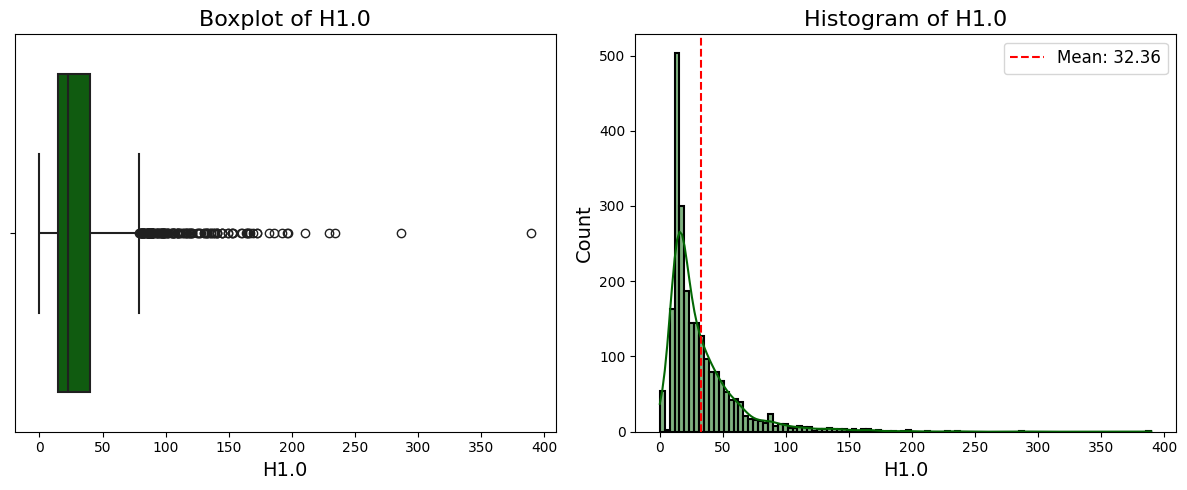

In [19]:
univariate_analysis(Bank_data, 'Н1.0')

#### Univariate Analysis of `H1.0`

- **Summary Statistics:**  
  - The mean value of `H1.0` is approximately **32.36**.  
  - The minimum value is **0.0**, while the maximum is **389.69**, indicating a wide range.  
  - The standard deviation is **29.28**, showing considerable spread.  
  - The median is **22.46**, with the 25th percentile at **14.41** and the 75th at **40.26**.  
  - The right-skewed distribution and high max value suggest the presence of significant outliers.

- **Boxplot:**  
  - The boxplot highlights a large number of outliers beyond the upper whisker, especially above 100.  
  - This suggests that some banks have unusually high `H1.0` values, which may warrant transformation or special handling.

- **Histogram + KDE:**  
  - The histogram confirms a **right-skewed distribution**, with most values concentrated below 50.  
  - The red dashed line represents the mean (≈32.36), which lies to the right of the peak, consistent with the skew.  
  - The majority of banks have `H1.0` values clustered between 0 and 50, with a long tail extending to the right.



Summary statistics for 'ROE':
count    2349.000000
mean        4.855062
std        82.664122
min      -361.540000
25%        -0.320000
50%         2.790000
75%         6.470000
max      3306.070000
Name: ROE, dtype: float64


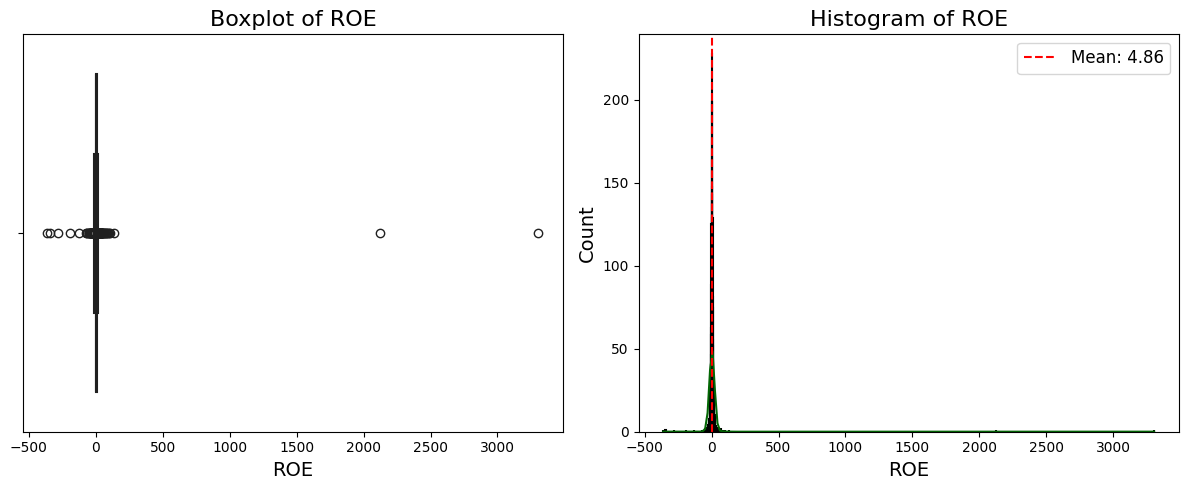

In [20]:
univariate_analysis(Bank_data, 'ROE')

#### Univariate Analysis of `ROE`

- **Summary Statistics:**  
  - The mean value of `ROE` is approximately **4.86**, while the median is **2.79**, indicating a slight right skew.  
  - The minimum value is **-361.50**, and the maximum is **3306.07**, suggesting the presence of extreme outliers.  
  - The standard deviation is **82.66**, which is high compared to the mean, reflecting substantial variability in the data.  
  - The interquartile range (IQR) lies between **-0.32** (25th percentile) and **6.47** (75th percentile).

- **Boxplot:**  
  - The boxplot shows several extreme outliers on both the negative and positive ends, with especially large positive values beyond 1000.  
  - This indicates that a few banks reported abnormally high or low ROE values, possibly due to unique events or data quality issues.

- **Histogram + KDE:**  
  - The distribution is **heavily right-skewed**, with most values concentrated near zero and a long tail stretching towards large positive outliers.  
  - The red dashed line representing the mean sits slightly right of the peak, confirming the skewed nature of the data.


Summary statistics for 'LN_Loans':
count    2354.000000
mean       22.439333
std         2.445192
min         0.000000
25%        20.762500
50%        22.240000
75%        23.907500
max        31.000000
Name: LN_Loans, dtype: float64


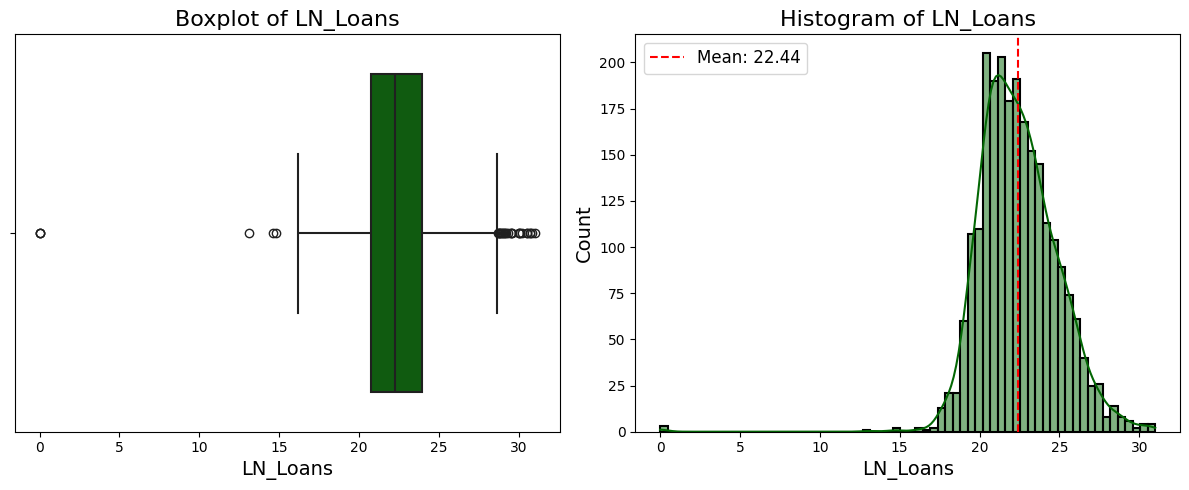

In [21]:
univariate_analysis(Bank_data, 'LN_Loans')

#### Univariate Analysis of `LN_Loans`

- **Summary Statistics:**  
  - The mean value of `LN_Loans` is approximately **22.44**, and the median is **22.24**, suggesting a fairly symmetric distribution.  
  - The standard deviation is **2.45**, indicating moderate variability.  
  - The 25th percentile is **20.76**, and the 75th is **23.91**, showing that most values are clustered within a tight range.  
  - The minimum value is **0.0**, which may be an outlier, while the maximum is **31.0**, slightly beyond the upper quartile range.

- **Boxplot:**  
  - The boxplot reveals a few mild outliers on both the lower and upper ends, particularly the zero value which appears to be an anomaly.  
  - The bulk of the data falls within the interquartile range, indicating concentration around the center.

- **Histogram + KDE:**  
  - The distribution appears to be **approximately normal with a slight right skew**.  
  - The histogram shows most values between 20 and 25, with the red dashed line (mean) closely aligned to the mode.  
  - The single extreme low value around zero significantly deviates from the rest and may require attention during preprocessing.



Summary statistics for 'LN_Securities':
count    2354.000000
mean       15.272362
std         9.854786
min         0.000000
25%         0.000000
50%        20.090000
75%        22.440000
max        29.280000
Name: LN_Securities, dtype: float64


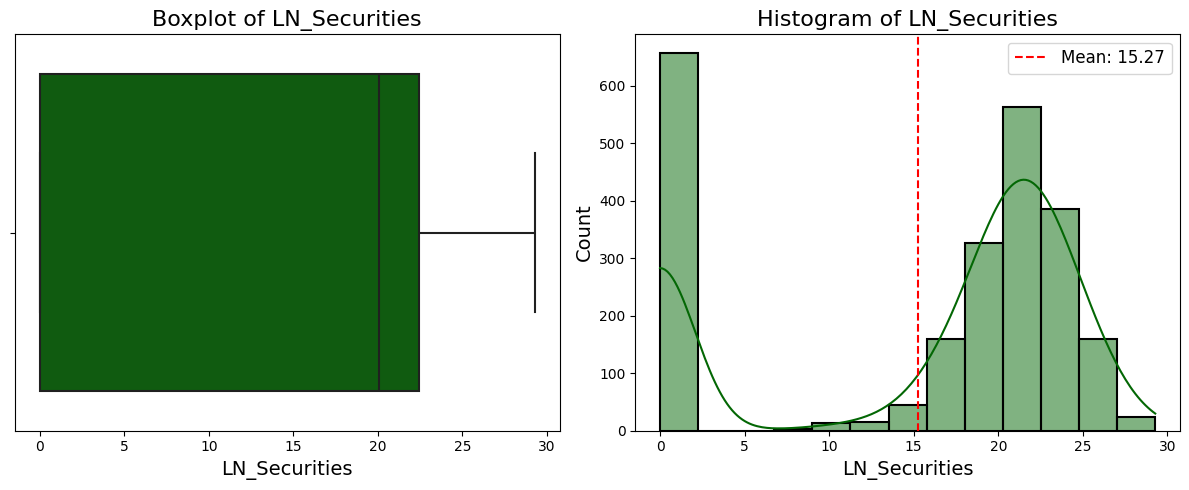

In [22]:
univariate_analysis(Bank_data, 'LN_Securities')

#### Univariate Analysis of `LN_Securities`

- **Summary Statistics:**  
  - The mean value of `LN_Securities` is approximately **15.27**, while the median is **20.09**, indicating left-skewness.  
  - The standard deviation is **9.85**, showing a relatively wide spread across the values.  
  - The 25th percentile is **0.0**, and the 75th is **22.44**, suggesting that a substantial portion of banks have minimal or no securities.  
  - The minimum value is **0.0**, and the maximum reaches **29.28**, showing variation in investment scale.

- **Boxplot:**  
  - The boxplot indicates a high concentration of values in the upper range, with a heavy lower tail at zero.  
  - There is no extreme outlier beyond the upper whisker, but a dense cluster of low values can be observed near the lower boundary.

- **Histogram + KDE:**  
  - The histogram reflects a **bimodal or left-skewed distribution**, with a large spike at zero, followed by a normal-like distribution of values above 10.  
  - The red dashed line (mean ≈15.27) is skewed leftward, deviating from the peak cluster near 20.  
  - The zero values likely represent banks with no investment in securities and may need special treatment depending on modeling requirements.


Summary statistics for 'LN_Deposits':
count    2354.000000
mean       21.642676
std         3.989488
min         0.000000
25%        20.322500
50%        21.890000
75%        23.670000
max        30.770000
Name: LN_Deposits, dtype: float64


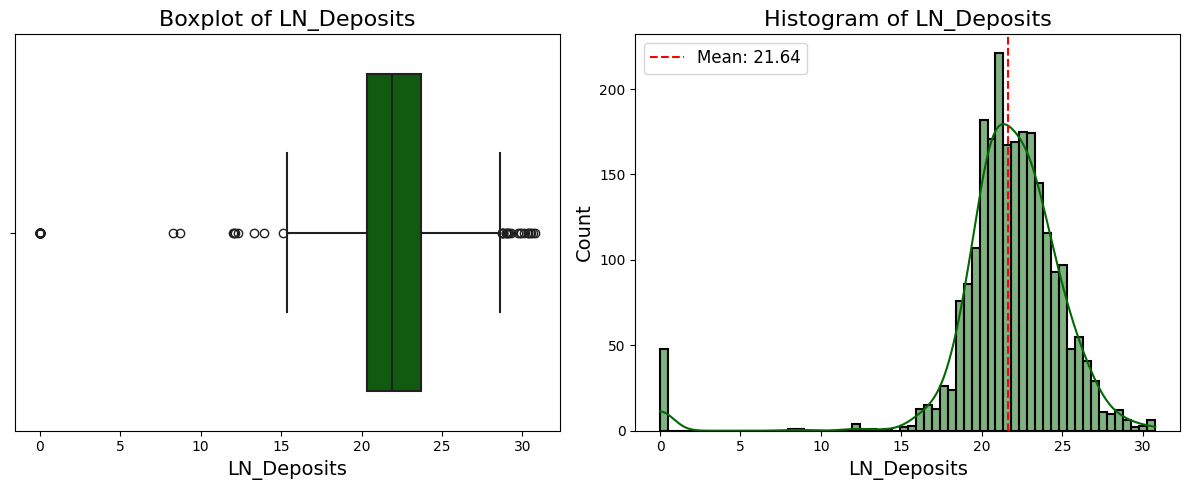

In [23]:
univariate_analysis(Bank_data, 'LN_Deposits')

#### Univariate Analysis of `LN_Deposits`

- **Summary Statistics:**  
  - The mean value of `LN_Deposits` is approximately **21.64**, while the median is **21.89**, indicating a fairly symmetric distribution.  
  - The standard deviation is **3.99**, showing moderate variability.  
  - The 25th percentile is **20.32**, and the 75th percentile is **23.67**, meaning most values are concentrated within a narrow range around the center.  
  - The minimum value is **0.0**, which may indicate missing or anomalous entries, while the maximum is **30.77**.

- **Boxplot:**  
  - The boxplot reveals a few low-end outliers, especially the zero values, which are significantly distant from the interquartile range.  
  - A moderate number of high-end values are present but fall within acceptable spread.

- **Histogram + KDE:**  
  - The distribution is **slightly left-skewed**, with the peak around 22 and a long left tail due to the zero values.  
  - The red dashed line representing the mean (≈21.64) is aligned with the peak, supporting the near-symmetric nature of the distribution.  
  


Summary statistics for 'LN_Equity':
count    2347.000000
mean       20.300550
std         7.683475
min       -28.010000
25%        20.025000
50%        21.090000
75%        22.600000
max        29.270000
Name: LN_Equity, dtype: float64


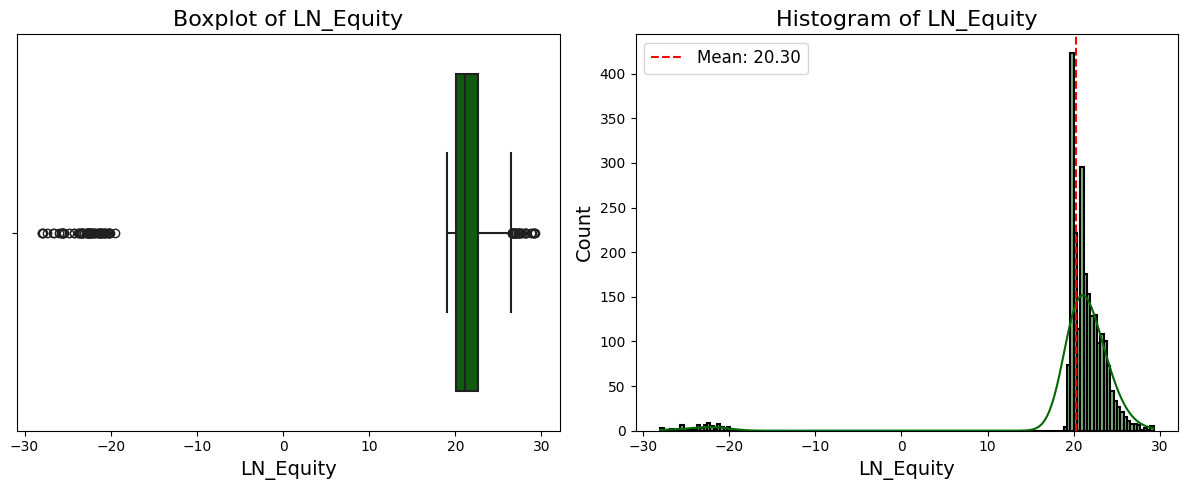

In [24]:
univariate_analysis(Bank_data, 'LN_Equity')

#### Univariate Analysis of `LN_Equity`

- **Summary Statistics:**  
  - The mean value of `LN_Equity` is approximately **20.30**, and the median is **21.09**, suggesting a slight left-skew.  
  - The standard deviation is **7.68**, indicating moderate variability with some spread.  
  - The 25th percentile is **20.03**, and the 75th percentile is **22.60**, showing that most values are concentrated in a narrow upper range.  
  - The minimum value is **-28.01**, which is highly unusual for a log-transformed financial metric and likely represents an extreme outlier.  
  - The maximum value is **29.27**, which aligns with the general scale of other balance sheet features.

- **Boxplot:**  
  - The boxplot reveals extreme negative outliers far outside the interquartile range. These values likely correspond to banks with very low or negative equity and may need special handling.  
  - Positive values are tightly clustered and form a symmetric box around the median.

- **Histogram + KDE:**  
  - The histogram confirms a **left-skewed distribution**, with most values centered between 20 and 25, and a long tail of negative outliers.  
  - The red dashed line (mean ≈20.30) lies close to the main density peak, reinforcing the dominance of values in the 20–25 range.  
  - The long left tail suggests potential issues with banks experiencing negative equity, which might impact modeling stability.



Summary statistics for 'LN_EBT':
count    2354.000000
mean       10.958003
std        15.678078
min       -26.540000
25%        15.410000
50%        18.090000
75%        20.170000
max        28.050000
Name: LN_EBT, dtype: float64


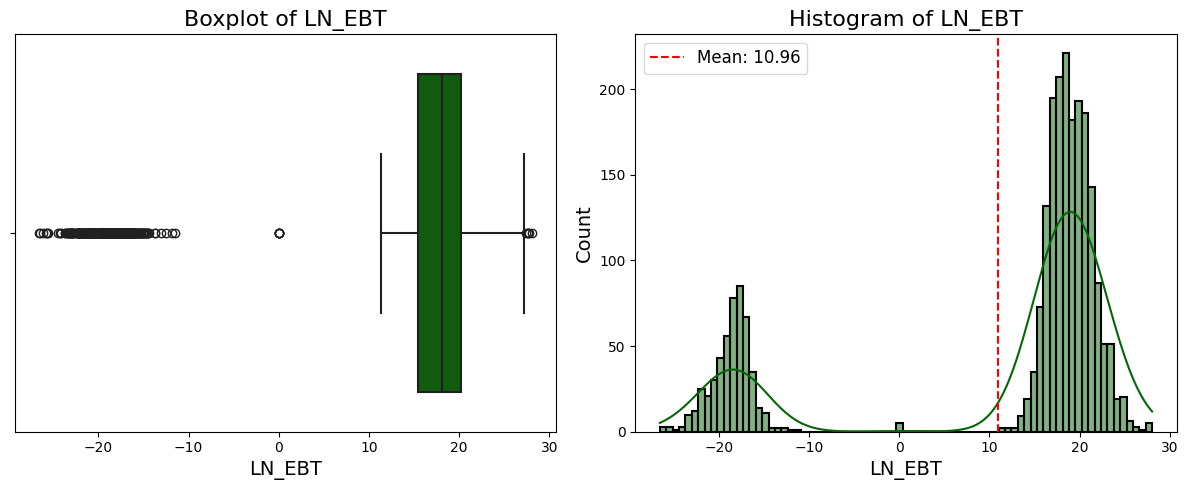

In [25]:
univariate_analysis(Bank_data, 'LN_EBT')

#### Univariate Analysis of `LN_EBT`

- **Summary Statistics:**  
  - The mean value of `LN_EBT` is approximately **10.96**, while the median is **18.0**, indicating a strong left-skewed distribution.  
  - The standard deviation is **15.68**, suggesting a high degree of variability.  
  - The 25th percentile is **15.41**, and the 75th percentile is **20.17**, showing that the majority of values are clustered within a narrow positive range.  
  - The minimum value is **-26.54**, and the maximum is **28.05**, highlighting the presence of extreme negative outliers.

- **Boxplot:**  
  - The boxplot displays significant left-sided outliers, with many values far below the interquartile range.  
  - Most values are concentrated between 15 and 25, but the long left tail is evident from the negative extremes.

- **Histogram + KDE:**  
  - The distribution is **bimodal and left-skewed**, with a large concentration of values in the higher positive range and a second, smaller peak in the negative zone.  
  - The red dashed line (mean ≈10.96) falls between the two peaks but is pulled leftward due to the influence of negative outliers.


Summary statistics for 'H4':
count    1993.000000
mean       38.507030
std        28.781439
min         0.000000
25%        14.440000
50%        36.220000
75%        57.770000
max       156.170000
Name: H4, dtype: float64


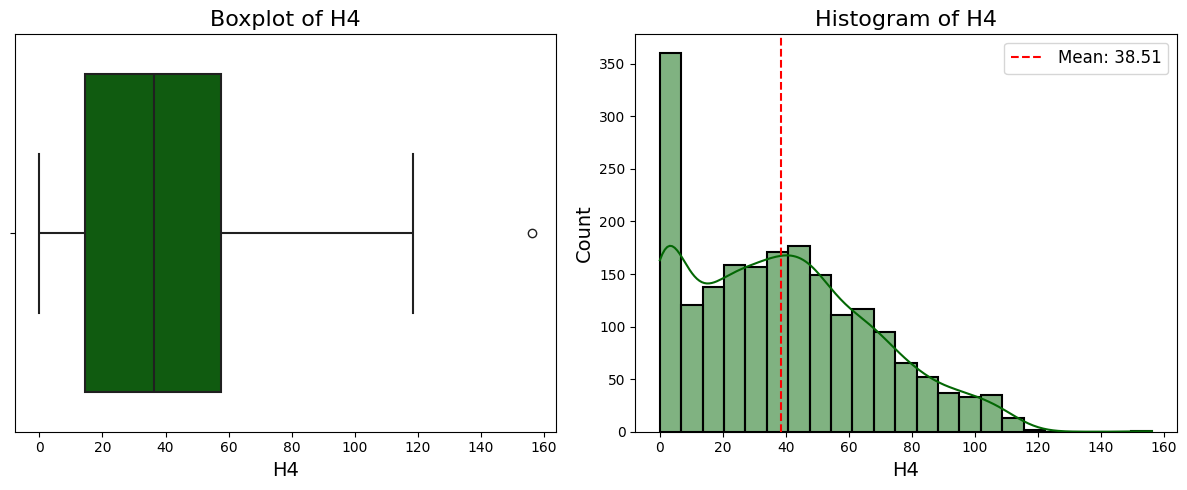

In [26]:
univariate_analysis(Bank_data, 'H4')

#### Univariate Analysis of `H4`

- **Summary Statistics:**  
  - The mean value of `H4` is approximately **38.51**, and the median is **36.22**, suggesting a slightly right-skewed distribution.  
  - The standard deviation is **28.78**, indicating substantial spread in the values.  
  - The 25th percentile is **14.44**, and the 75th percentile is **57.77**, showing that most values lie between 14 and 58.  
  - The minimum value is **0.0**, and the maximum is **156.17**, reflecting some potential high-end outliers.

- **Boxplot:**  
  - The boxplot appears mostly symmetric, with one prominent outlier above 150.  
  - The values are otherwise fairly well-distributed within the interquartile range, and no extreme skew is evident in the central box.

- **Histogram + KDE:**  
  - The histogram shows a **right-skewed distribution**, with a high concentration of values at the lower end (close to 0) and a gradual decline toward higher values.  
  - The red dashed line (mean ≈38.51) lies slightly to the right of the main peak, consistent with the long right tail.  
  - The spike at zero may indicate structural zeroes or special cases worth exploring further.


Summary statistics for 'ROA':
count    2354.000000
mean        0.467655
std         2.482019
min       -49.810000
25%        -0.070000
50%         0.540000
75%         1.190000
max        29.110000
Name: ROA, dtype: float64


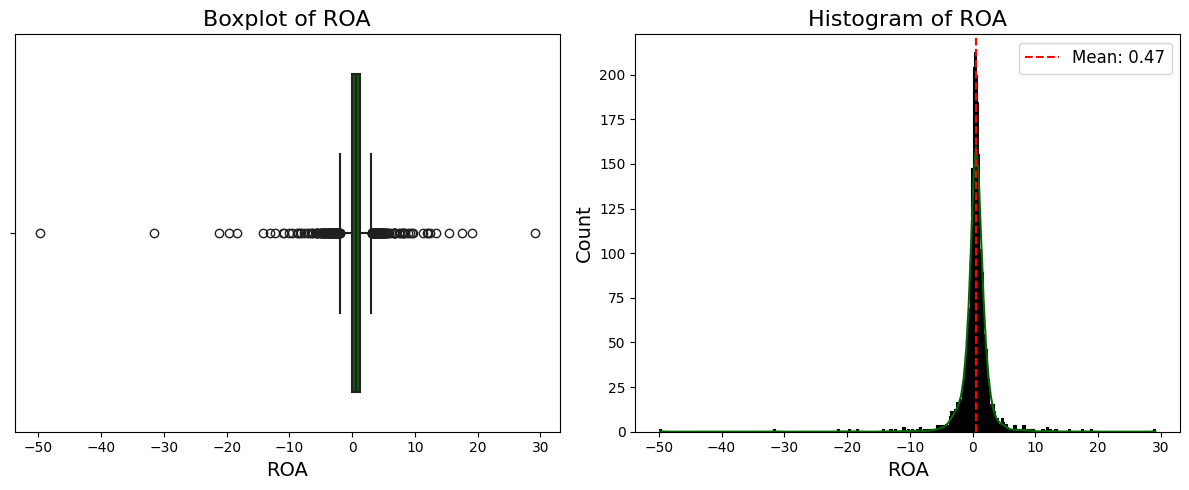

In [27]:
univariate_analysis(Bank_data, 'ROA')

#### Univariate Analysis of `ROA`

- **Summary Statistics:**  
  - The mean value of `ROA` is approximately **0.47**, and the median is **0.54**, indicating a nearly symmetric distribution centered around zero.  
  - The standard deviation is **2.48**, reflecting a relatively narrow spread in most values.  
  - The 25th percentile is **-0.07**, and the 75th percentile is **1.19**, suggesting that the majority of values lie within a small range around zero.  
  - The minimum value is **-49.81**, and the maximum is **29.11**, indicating the presence of extreme outliers on both tails.

- **Boxplot:**  
  - The boxplot shows a dense concentration of values near the center, with numerous outliers on both the negative and positive sides.  
  - The left tail is particularly heavy, with several points far below the lower whisker, potentially from banks with significant losses.

- **Histogram + KDE:**  
  - The histogram displays a **sharp peak centered around zero**, with a steep drop-off on both sides.  
  - The red dashed line (mean ≈0.47) aligns closely with the center of the distribution.  
  - The long tails highlight the influence of outliers, though most banks maintain a ROA close to zero or slightly positive.


Summary statistics for 'Overdue_debt_ratio':
count    2332.000000
mean       12.235425
std        52.294082
min         0.000000
25%         1.935000
50%         5.240000
75%        11.450000
max      2390.450000
Name: Overdue_debt_ratio, dtype: float64


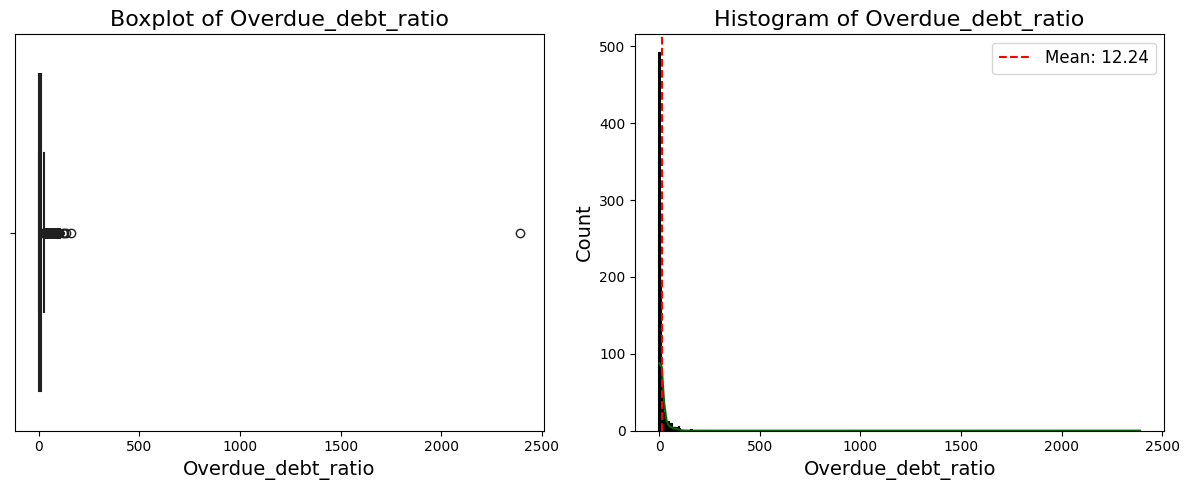

In [28]:
univariate_analysis(Bank_data, 'Overdue_debt_ratio')

#### Univariate Analysis of `Overdue_debt_ratio`

- **Summary Statistics:**  
  - The mean value is approximately **12.24**, while the median is significantly lower at **5.24**, indicating a strong right-skew.  
  - The standard deviation is very high at **52.29**, reflecting extreme variability in overdue debt ratios across banks.  
  - The 25th percentile is **1.94**, and the 75th percentile is **11.45**, showing that most values fall within a relatively narrow range.  
  - The minimum value is **0.0**, while the maximum is a striking **2390.45**, indicating a potential outlier or data anomaly.

- **Boxplot:**  
  - The boxplot highlights numerous extreme outliers far beyond the upper whisker, particularly the single extreme case near 2400.  
  - The bulk of the values are compressed near the lower end of the scale, with very little visible box area due to the extreme values pulling the scale.

- **Histogram + KDE:**  
  - The histogram confirms a **heavily right-skewed distribution**, with a sharp peak near zero and a long tail extending far right.  
  - The red dashed line (mean ≈12.24) is pulled far to the right due to the presence of very large outliers.  
  - Most banks have relatively low overdue debt ratios, but a few institutions exhibit extreme cases.


### Univariate Analysis of Categorical Variable:

#### 1. Year

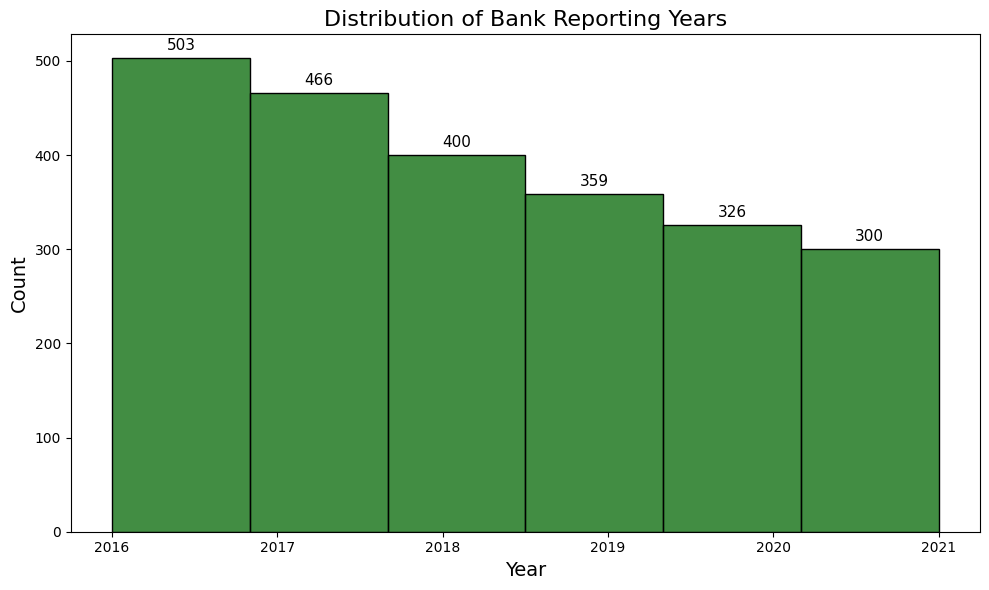

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the histogram
plt.figure(figsize=(10, 6))
ax = sns.histplot(Bank_data['Year'], bins=6, color='#036704')

# Add title and labels
plt.title('Distribution of Bank Reporting Years', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Count', fontsize=14)

# Add data labels on top of each bar
for bar in ax.patches:
    height = bar.get_height()
    if height > 0:  # Skip if bar has 0 height
        ax.text(bar.get_x() + bar.get_width() / 2,
                height + 5,  # Adjust vertical position
                f'{int(height)}',
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()


#### Distribution of Bank Reporting Years

The bar plot above illustrates the number of bank-year observations reported from **2016 to 2021**.

- The dataset shows a **gradual decline** in the number of banks reporting financial data over time.  
- In **2016**, the dataset includes the highest count with **503** banks, followed by **466** in 2017 and **400** in 2018.  
- This downward trend continues, with only **300** banks reporting in **2021**, indicating possible market exits, in later years.

**Insights:**  
- The decreasing pattern may reflect structural changes in the Russian banking sector over the period studied, including closures, mergers, or increased regulatory pressure.  


Value counts for 'Status':
Status
Active                   1696
Inactive                  381
In bankruptcy             197
It's being liquidated      53
Reorganizing               27
Name: count, dtype: int64
Number of unique categories: 5
--------------------------------------------------


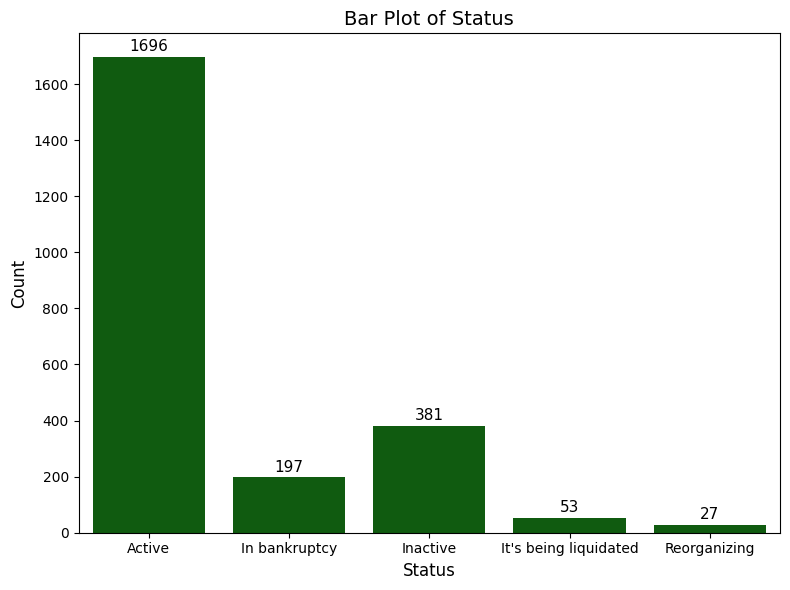

In [30]:
# Value counts for 'Status'
print("Value counts for 'Status':")
print(Bank_data['Status'].value_counts(dropna=False))
print("Number of unique categories:", Bank_data['Status'].nunique())
print("-" * 50)

# Bar plot with labels
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=Bank_data, x='Status', color='#036704')  # <-- Capture the plot in 'ax'
plt.title("Bar Plot of Status", fontsize=14)
plt.xlabel("Status", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Add data labels on top of bars
for bar in ax.patches:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2,
            height + 10,  # adjust label position above bar
            f'{int(height)}',
            ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()


#### Distribution of Bank Operational Status

The bar plot above shows the distribution of bank operational statuses in the dataset. There are **5 unique categories** captured under the `Status` variable:

- **Active**: 1,696 banks  
- **Inactive**: 381 banks  
- **In bankruptcy**: 197 banks  
- **It’s being liquidated**: 53 banks  
- **Reorganizing**: 27 banks  

**Insights:**  
- The vast majority of banks are marked as **Active**, making up nearly 72% of the total observations.  
- A non-negligible number of banks are either **Inactive**, in **Bankruptcy**, or undergoing structural transitions like **Liquidation** or **Reorganization**.  
- These status categories are important indicators of financial health and could have a strong relationship with the target variable `Hedge_indicator`.

Top 20 Banks by Frequency:
Bank
JuNIKREDIT BANK, AO                       6
ALMAZERGIENBANK AO, AKB                   6
TIN'KOFF BANK, AO                         6
SLAVIJa (AO), AKB                         6
ALTAJKAPITALBANK, OOO KB                  6
NOOSFERA (AO), AKB                        6
BANK PTB (OOO)                            6
MEZhDUNARODNYJ FINANSOVYJ KLUB, AO AKB    6
OB'EDINENNYJ KAPITAL, AO BANK             6
IT BANK, AO                               6
KROSNA-BANK, AO                           6
AK BARS BANK, PAO                         6
BANK BKF, OOO                             6
KUB (AO), BANK                            6
GARANT-INVEST (AO), KB                    6
BANK RMP (AO)                             6
JaRINTERBANK (OOO), IKBR                  6
ZIRAAT BANK (MOSKVA) (AO)                 6
SITIBANK, AO KB                           6
PSKB, AO BANK                             6
Name: count, dtype: int64
Number of unique banks: 529
----------------------------------

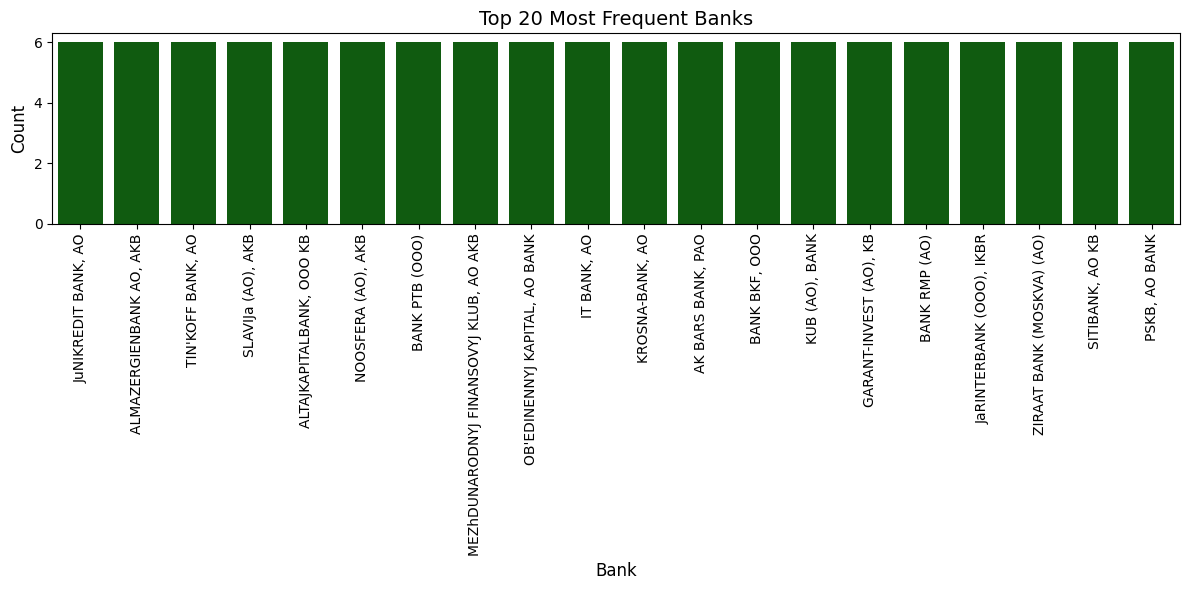

In [31]:
# Value counts for 'Bank'
print("Top 20 Banks by Frequency:")
top_20_banks = Bank_data['Bank'].value_counts(dropna=False).head(20)
print(top_20_banks)
print("Number of unique banks:", Bank_data['Bank'].nunique())
print("-" * 50)

# Bar plot (Top 20 only for readability)
plt.figure(figsize=(12, 6))
top_banks = top_20_banks.index
sns.countplot(data=Bank_data[Bank_data['Bank'].isin(top_banks)], x='Bank', color='#036704', order=top_banks)
plt.title("Top 20 Most Frequent Banks", fontsize=14)
plt.xlabel("Bank", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


#### Top 20 Most Frequently Reported Banks

The bar plot above displays the 20 most frequent banks in the dataset based on their appearance across years.

- Each of the top 20 banks appears **exactly 6 times**, which aligns with the 6-year time span from **2016 to 2021**.  
- This suggests that these banks have **complete reporting history** throughout the observed period, providing consistent panel data.  
- The dataset includes **529 unique banks** in total, indicating a diverse population of institutions with varying reporting frequencies.


In [32]:
# Step 1: Get the last year each bank appears
last_year_status = (
    Bank_data.sort_values('Year')
             .groupby('Bank')
             .tail(1)[['Bank', 'Year', 'Status']]
             .rename(columns={'Year': 'Last_Year', 'Status': 'Last_Reported_Status'})
)

# Step 2: Group by Bank for frequency and years active
bank_summary = Bank_data.groupby('Bank').agg(
    Frequency=('Bank', 'count'),
    Years_Active=('Year', lambda x: sorted(x.unique().tolist()))
).reset_index()

# Step 3: Merge last status info
bank_summary = bank_summary.merge(last_year_status, on='Bank', how='left')

# Display result
print("Bank Summary Table:")
print(bank_summary)
display(bank_summary)

Bank Summary Table:
                          Bank  Frequency  \
0               AB ROSSIJa, AO          6   
1     ABSOLJuT BANK (PAO), AKB          6   
2              AGORA OOO, BANK          6   
3        AGROPROMKREDIT, AO KB          6   
4            AGROSOJuZ, OOO KB          2   
..                         ...        ...   
524  ZIRAAT BANK (MOSKVA) (AO)          6   
525         ZLATKOMBANK, AO KB          2   
526         ZhILKREDIT, OOO KB          3   
527       ZhILSTROJBANK, AO KB          3   
528          ZhIVAGO BANK, OOO          6   

                             Years_Active  Last_Year Last_Reported_Status  
0    [2016, 2017, 2018, 2019, 2020, 2021]       2021               Active  
1    [2016, 2017, 2018, 2019, 2020, 2021]       2021               Active  
2    [2016, 2017, 2018, 2019, 2020, 2021]       2021               Active  
3    [2016, 2017, 2018, 2019, 2020, 2021]       2021               Active  
4                            [2016, 2017]       2017       

,Bank,Frequency,Years_Active,Last_Year,Last_Reported_Status
0,"AB ROSSIJa, AO",6,"[2016, 2017, 2018, 2019, 2020, 2021]",2021,Active
1,"ABSOLJuT BANK (PAO), AKB",6,"[2016, 2017, 2018, 2019, 2020, 2021]",2021,Active
2,"AGORA OOO, BANK",6,"[2016, 2017, 2018, 2019, 2020, 2021]",2021,Active
3,"AGROPROMKREDIT, AO KB",6,"[2016, 2017, 2018, 2019, 2020, 2021]",2021,Active
4,"AGROSOJuZ, OOO KB",2,"[2016, 2017]",2017,In bankruptcy
...,...,...,...,...,...
524,ZIRAAT BANK (MOSKVA) (AO),6,"[2016, 2017, 2018, 2019, 2020, 2021]",2021,Active
525,"ZLATKOMBANK, AO KB",2,"[2016, 2017]",2017,In bankruptcy
526,"ZhILKREDIT, OOO KB",3,"[2016, 2017, 2018]",2018,In bankruptcy
527,"ZhILSTROJBANK, AO KB",3,"[2016, 2017, 2018]",2018,Inactive


#### Bank Frequency and Reporting Patterns

The table above highlights the reporting behavior of individual banks over the 6-year period from **2016 to 2021**.

- Several banks (e.g., **AB ROSSIJa, AO**, **ABSOLJuT BANK**, **AGORA OOO**) have complete reporting records, appearing consistently across all 6 years.
- These banks typically have a `Last_Reported_Status` of **Active**, indicating ongoing operations and full engagement in financial reporting.
- In contrast, other banks (e.g., **AGROSOJuZ**, **ZLATKOMBANK**, **ZhiLKREDIT**) appear for only 2–3 years and often show a final status of **In bankruptcy** or **Inactive**, reflecting operational disruptions or closures.

This view offers a foundational understanding of institutional longevity and status transitions that could be valuable for both predictive modeling and exploratory insight generation.


Value counts for 'Hedge_indicator':
Hedge_indicator
0    2165
1     189
Name: count, dtype: int64
Number of unique categories: 2
--------------------------------------------------


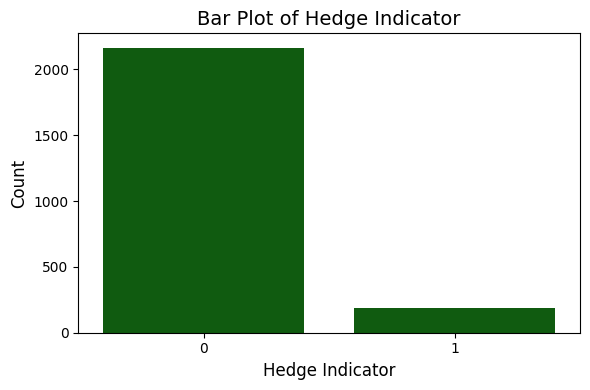

In [33]:
# Value counts for 'Hedge_indicator'
print("Value counts for 'Hedge_indicator':")
print(Bank_data['Hedge_indicator'].value_counts(dropna=False))
print("Number of unique categories:", Bank_data['Hedge_indicator'].nunique())
print("-" * 50)

# Bar plot
plt.figure(figsize=(6, 4))
sns.countplot(data=Bank_data, x='Hedge_indicator', color='#036704')
plt.title("Bar Plot of Hedge Indicator", fontsize=14)
plt.xlabel("Hedge Indicator", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()


#### Distribution of `Hedge_indicator`

The bar plot above displays the distribution of the target variable `Hedge_indicator`, which identifies whether a bank engaged in swap-hedging:

- **0** (Did not hedge): 2,165 observations  
- **1** (Did hedge): 189 observations  
- Total number of unique categories: 2

**Insights:**  
- The dataset is **highly imbalanced**, with only about **8%** of observations indicating hedge adoption.  
- Such imbalance can significantly affect model training and performance, particularly for classification algorithms biased toward the majority class.


### Bivariate Analysis:  Numerical Variable Vs Numerical Variable:

#### 1. Heatmap Between Numerical variables:

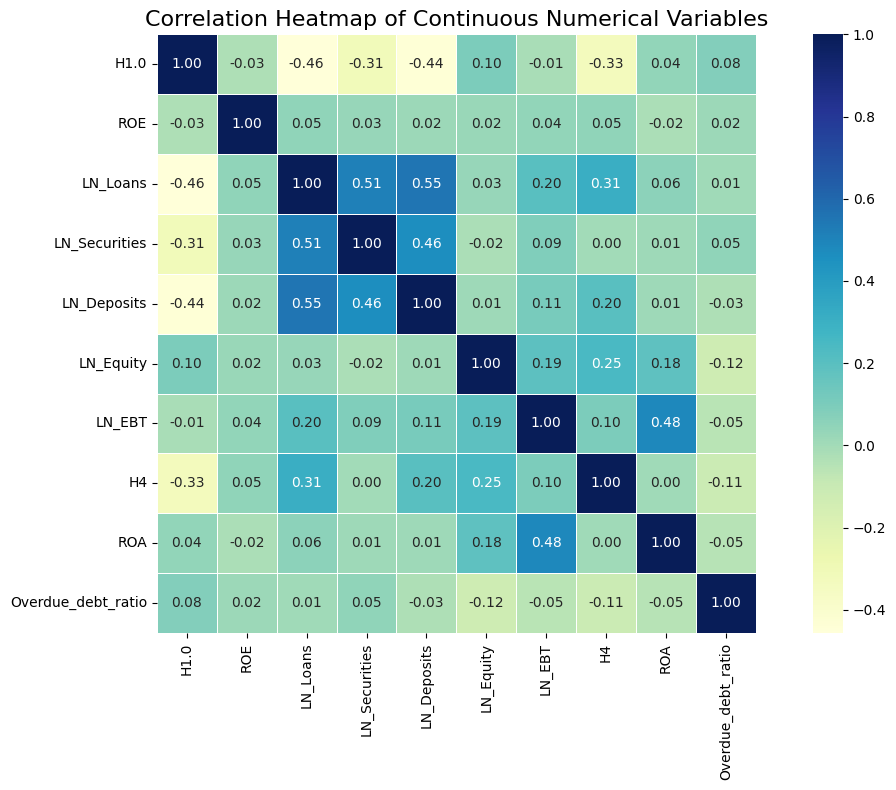

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Select only true continuous numeric columns (exclude Year and Hedge_indicator)
numeric_cols = Bank_data.select_dtypes(include=['float64', 'int64']).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ['Year', 'Hedge_indicator']]

# 2. Compute correlation matrix
correlation_matrix = Bank_data[numeric_cols].corr()

# 3. Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='YlGnBu', linewidths=0.5, square=True)
plt.title("Correlation Heatmap of Continuous Numerical Variables", fontsize=16)
plt.tight_layout()
plt.show()



#### Correlation Heatmap of Continuous Numerical Variables

The heatmap above illustrates the pairwise Pearson correlation coefficients among continuous numerical variables in the dataset.

**Key Observations:**

- **Strong Positive Correlations:**
  - `LN_Loans` and `LN_Deposits`: **0.55**
  - `LN_Loans` and `LN_Securities`: **0.51**
  - `LN_Securities` and `LN_Deposits`: **0.46**  
  These suggest that banks with larger loan portfolios also tend to have higher securities holdings and deposits, reflecting scale effects in balance sheet structure.

- **Moderate Relationships:**
  - `LN_Equity` shows moderate correlation with `H4` (**0.25**) and `ROA` (**0.18**), indicating possible links between capital levels, risk compliance, and profitability.

- **Weak or Negligible Correlations:**
  - Variables like `ROE`, `Overdue_debt_ratio`, and `H1.0` show low correlation with most features.
  - `H1.0` has moderate negative correlation with `LN_Loans` (**-0.46**) and `LN_Deposits` (**-0.44**), possibly indicating higher capital adequacy in lower-exposure banks.

**Insights:**

- There is **no evidence of multicollinearity** that would prevent multiple variables from being used together in modeling, though caution is advised for pairs with r > 0.5.
- These correlations provide guidance for feature selection, dimensionality reduction, or understanding economic relationships among indicators.


### Bivariate Analysis:  Categorical Variable Vs Categorical Variable:



#### 1. Status Vs year

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set font and palette
sns.set(font_scale=1.3)
palette = sns.color_palette("Set2", 2)

# Create a copy of the dataset
bank_copy = Bank_data.copy()

# Add string versions of Year and Hedge_indicator
bank_copy['Year_str'] = bank_copy['Year'].astype(str)
bank_copy['Hedge_str'] = bank_copy['Hedge_indicator'].astype(str)


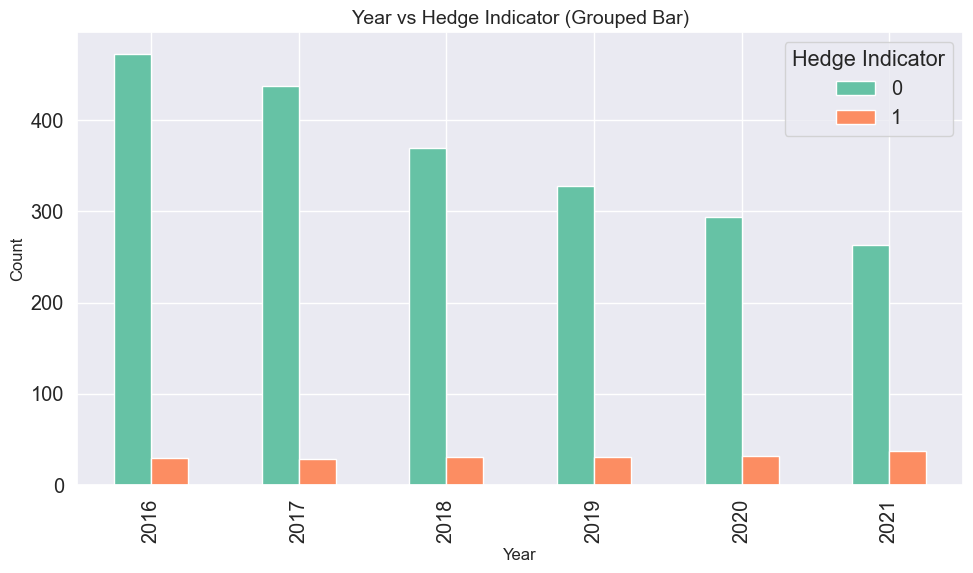

In [36]:
grouped_year_hedge = bank_copy.groupby(['Year_str', 'Hedge_str']).size().unstack(fill_value=0)

grouped_year_hedge.plot(kind='bar', stacked=False, figsize=(10, 6), color=palette)
plt.title("Year vs Hedge Indicator (Grouped Bar)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(title="Hedge Indicator")
plt.tight_layout()
plt.show()


#### Bivariate Analysis: Year vs `Hedge_indicator`

The grouped bar chart above displays the count of hedge and non-hedge observations by year from 2016 to 2021.

**Key Observations:**

- Across all years, the number of banks **not engaging in hedge activity (`Hedge_indicator = 0`)** far exceeds those that do.  
- The count of banks using swap-hedging (`Hedge_indicator = 1`) remains consistently low across years but **shows a gradual increase from 2016 to 2021**.
- Notably, in **2021**, the number of hedging banks reaches its **highest level**, while the total number of reporting banks is at its lowest, suggesting **increased hedging adoption despite sector shrinkage**.

**Insights:**

- The hedge adoption trend, although small in absolute terms, may reflect **growing awareness or regulatory push toward risk management** practices over time.


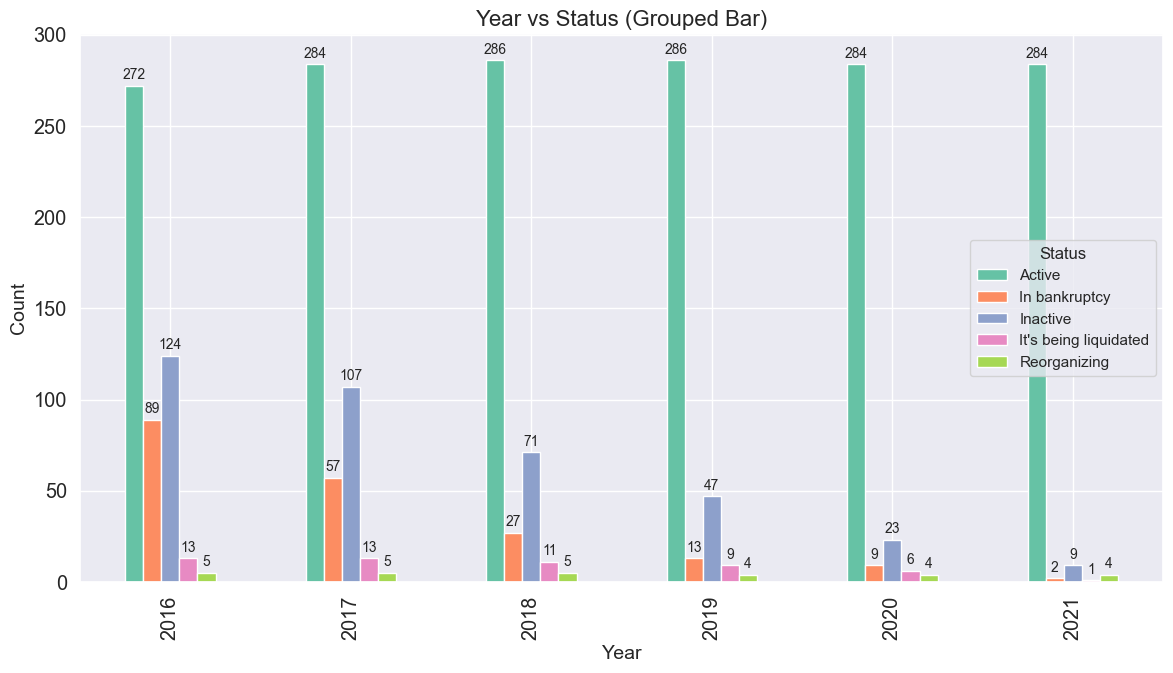

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Copy the data
bank_copy = Bank_data.copy()
bank_copy['Year_str'] = bank_copy['Year'].astype(str)

# Group the data
grouped_status_year = bank_copy.groupby(['Year_str', 'Status']).size().unstack(fill_value=0)

# Create a custom color palette for ALL unique statuses
num_statuses = grouped_status_year.shape[1]
palette = sns.color_palette("Set2", num_statuses)  # Extend to as many as needed

# Plot
ax = grouped_status_year.plot(kind='bar', stacked=False, figsize=(12, 7), color=palette)
plt.title("Year vs Status (Grouped Bar)", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.legend(title="Status", fontsize=11, title_fontsize=12)

# Add count labels on top of each bar
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2,
                    height + 2,
                    f'{int(height)}',
                    ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


#### Bivariate Analysis: Year vs `Status`

The grouped bar chart above presents the distribution of bank operational statuses across the years 2016 to 2021.

**Key Observations:**

- The **"Active"** status dominates consistently across all years, with counts hovering around **272 to 286** banks per year.
- The number of banks **"In bankruptcy"** shows a clear decline from **89 in 2016** to just **2 in 2021**, indicating sector stabilization or resolution of prior financial distress.
- Similarly, **"Inactive"** banks reduce gradually from **124 in 2016** to **9 by 2021**, which could reflect liquidation or recovery.
- The counts for **"It’s being liquidated"** and **"Reorganizing"** remain low and relatively stable across the timeline.


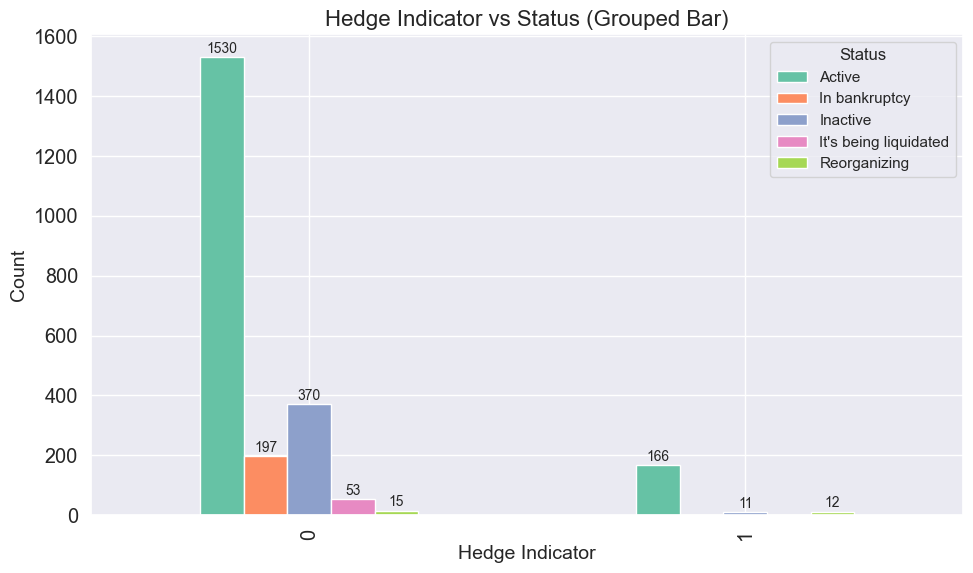

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Copy the original data
bank_copy = Bank_data.copy()

# Create string version of Hedge_indicator for clean x-axis labels
bank_copy['Hedge_str'] = bank_copy['Hedge_indicator'].astype(str)

# Group by Hedge_indicator and Status
grouped_hedge_status = bank_copy.groupby(['Hedge_str', 'Status']).size().unstack(fill_value=0)

# Create color palette for each unique status
num_statuses = grouped_hedge_status.shape[1]
palette = sns.color_palette("Set2", num_statuses)

# Plot grouped bar chart
ax = grouped_hedge_status.plot(kind='bar', stacked=False, figsize=(10, 6), color=palette)
plt.title("Hedge Indicator vs Status (Grouped Bar)", fontsize=16)
plt.xlabel("Hedge Indicator", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.legend(title="Status", fontsize=11, title_fontsize=12)

# Add data labels
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    height + 5,
                    f'{int(height)}',
                    ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


#### Bivariate Analysis: `Hedge_indicator` vs `Status`

The grouped bar chart above displays the distribution of bank statuses (`Status`) across the two categories of the target variable `Hedge_indicator`.

**Key Observations:**

- Among banks **not engaging in hedging (`Hedge_indicator = 0`)**, the majority are **Active (1,530)**, followed by **Inactive (370)** and **In bankruptcy (197)**.  
- In contrast, among banks that **do hedge (`Hedge_indicator = 1`)**, almost all are **Active (166 out of 189 total)**, with very few listed as **Inactive (11)** or **Reorganizing (12)**.
- Notably, **no banks marked as “In bankruptcy” or “Being liquidated”** are reported as using swap-hedging strategies.

**Insights:**

- Hedge adoption is **strongly concentrated among Active banks**, reinforcing the idea that **financially stable institutions are more likely to use sophisticated risk management tools**.
- Banks in distress or undergoing dissolution are unlikely to hedge, potentially due to lack of operational continuity or strategic capacity.


### Bivariate Analysis:  Numerical Variable Vs Categorical Variable:

#### 1. Status vs Numerical columns

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

def bivariate_boxplot(df, cat_col, num_col, palette='Pastel1'):
    """
    Draws a boxplot comparing a numerical variable with a categorical variable.

    Parameters:
    df (DataFrame): The input DataFrame.
    cat_col (str): Categorical column name (e.g., 'Status').
    num_col (str): Numerical column name (e.g., 'ROE').
    palette (str): Seaborn color palette for the plot.
    """
    if cat_col not in df.columns or num_col not in df.columns:
        print(f"Error: '{cat_col}' or '{num_col}' not found in the DataFrame.")
        return

    if not pd.api.types.is_numeric_dtype(df[num_col]):
        print(f"Error: '{num_col}' is not a numeric column.")
        return

    plt.figure(figsize=(8, 5))
    sns.boxplot(x=cat_col, y=num_col, data=df, palette=palette)
    plt.title(f'{num_col} by {cat_col}', fontsize=14)
    plt.xlabel(cat_col, fontsize=12)
    plt.ylabel(num_col, fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


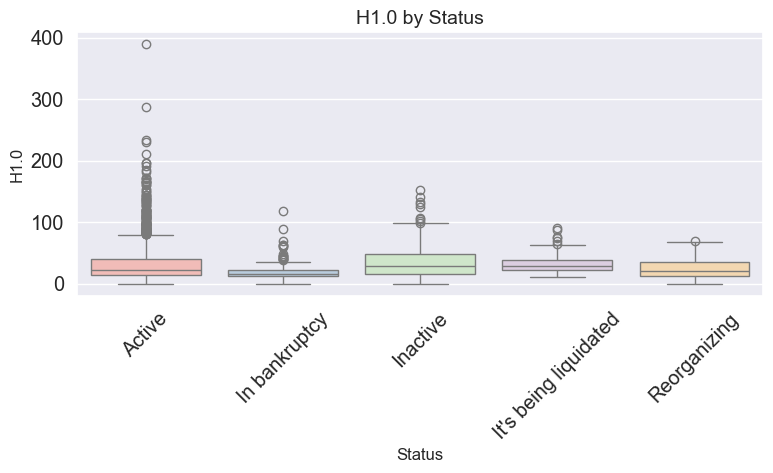

In [40]:
bivariate_boxplot(Bank_data, cat_col='Status', num_col='Н1.0')


#### Bivariate Analysis: `H1.0` by `Status`

The boxplot above illustrates the distribution of the `H1.0` variable.

**Key Observations:**

- **Active banks** show a wide distribution of `H1.0` values with numerous high outliers, indicating variation in capital positioning and potentially stronger capitalization on average.
- **Inactive** and **In bankruptcy** banks exhibit more compact distributions, with lower medians and fewer extreme values, suggesting more constrained capital adequacy or conservative reporting.
- **“It’s being liquidated”** and **“Reorganizing”** banks have the tightest distributions with limited variance, potentially due to frozen or closely monitored capital positions during restructuring.
- All categories have outliers, but **Active banks** show the highest range and frequency of extreme values (some above 300–400), possibly reflecting diverse business strategies or sizes.

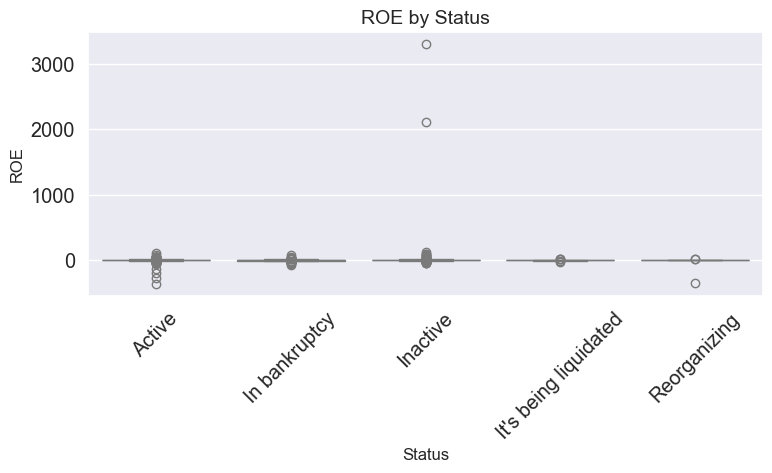

In [41]:
bivariate_boxplot(Bank_data, cat_col='Status', num_col='ROE')


#### Bivariate Analysis: `ROE` by `Status`

The boxplot above presents the distribution of `ROE` (Return on Equity) across different bank status categories.

**Key Observations:**

- All groups show a tightly packed interquartile range near zero, but the presence of extreme **positive outliers** especially among **Inactive** banks is significant.  
  - Some `ROE` values exceed **3000**, likely due to highly volatile or anomalous financial conditions in smaller or distressed banks.
- **Active** banks maintain a relatively stable `ROE` distribution, with fewer extreme outliers and a concentration of values closer to normal profitability levels.
- **In bankruptcy**, **liquidated**, and **reorganizing** banks also exhibit tight clusters around the zero mark, often with negative or low-positive returns, suggesting minimal or no profitability.


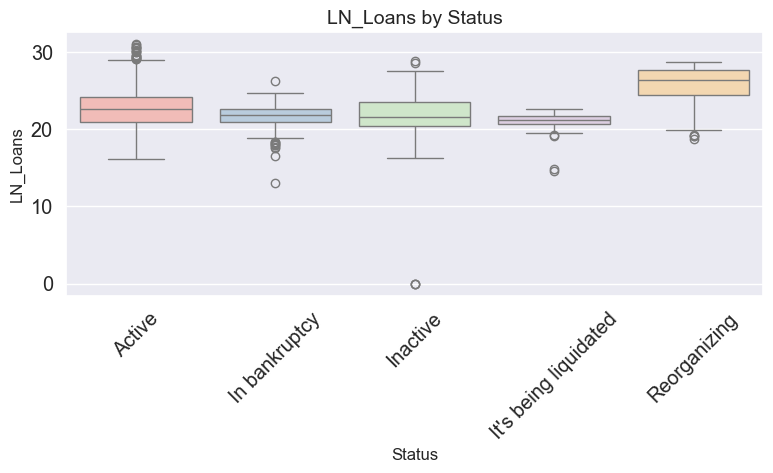

In [42]:
bivariate_boxplot(Bank_data, cat_col='Status', num_col='LN_Loans')


#### Bivariate Analysis: `LN_Loans` by `Status`

The boxplot above compares the distribution of `LN_Loans` (log-transformed loan volumes) across different bank status categories.

**Key Observations:**

- **Active banks** show a broad spread in loan volumes, with a higher median and extreme outliers, indicating substantial variation in loan portfolio sizes.
- **Reorganizing banks** also demonstrate a relatively high and compact distribution, suggesting that some institutions undergoing restructuring still manage sizable loan books.
- **Inactive** and **In bankruptcy** banks show slightly lower medians and tighter interquartile ranges, reflecting reduced lending activity or conservatism due to operational constraints.
- **“It’s being liquidated”** banks exhibit the most compact and lowest distribution of loan values, consistent with wind-down operations.

- `LN_Loans` is likely a useful feature for modeling hedge behavior or financial strength, especially when combined with status-related indicators.

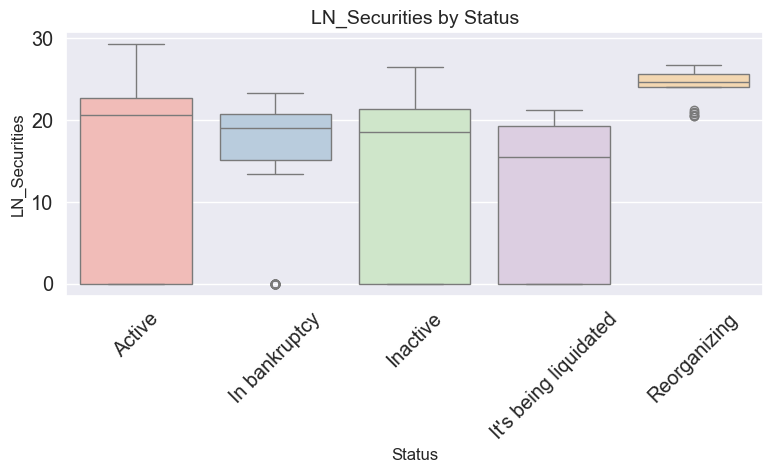

In [43]:
bivariate_boxplot(Bank_data, cat_col='Status', num_col='LN_Securities')


#### Bivariate Analysis: `LN_Securities` by `Status`

The boxplot above illustrates the distribution of `LN_Securities` (log-transformed value of securities held) across bank status categories.

**Key Observations:**

- **Active banks** show a wide range of securities holdings with several institutions reporting near-zero values, indicating diverse investment strategies or size disparities.
- **Reorganizing banks** exhibit the highest median and narrowest interquartile range, suggesting a tightly regulated or strategically maintained portfolio during reorganization.
- **In bankruptcy** and **Inactive** banks have similar distributions, with moderately high medians but greater variance than reorganizing banks.
- **Banks being liquidated** show slightly lower medians and compressed spreads, consistent with divestment of assets or halted investment activity.



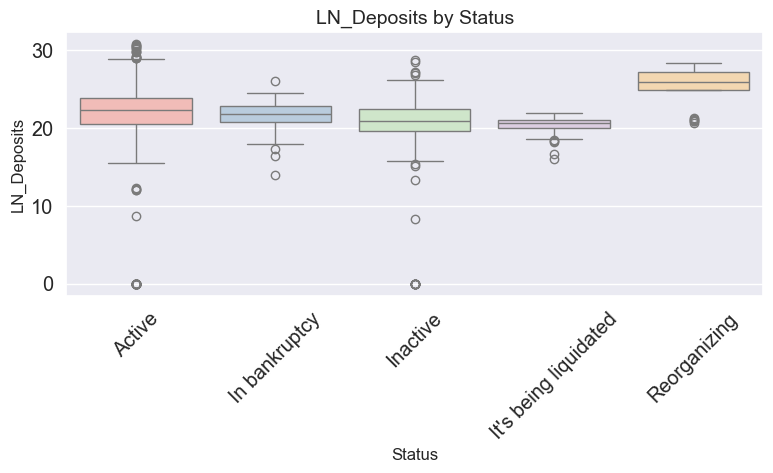

In [44]:
bivariate_boxplot(Bank_data, cat_col='Status', num_col='LN_Deposits')


#### Bivariate Analysis: `LN_Deposits` by `Status`

The boxplot above compares the distribution of `LN_Deposits` (log-transformed deposit volume) across different bank statuses.

**Key Observations:**

- **Active banks** exhibit a broad range of deposit values, with a higher median and several low-end outliers, possibly due to differing bank sizes or operational focuses.
- **Reorganizing banks** have the **highest median deposit levels** and a tightly packed interquartile range, suggesting maintained customer trust or regulatory support during restructuring.
- **In bankruptcy**, **Inactive**, and **Liquidating** banks show more constrained distributions with moderate medians, consistent with declining customer activity or operational wind-downs.
- A few **zero or near-zero deposit values** appear across various groups, likely representing edge cases or defunct institutions.


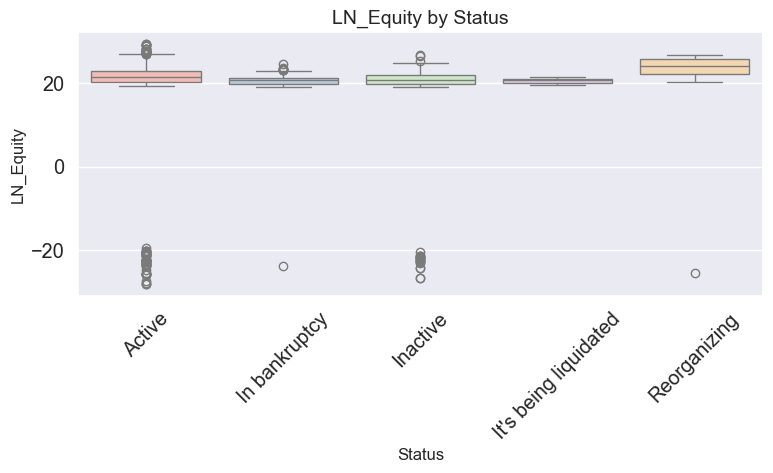

In [45]:
bivariate_boxplot(Bank_data, cat_col='Status', num_col='LN_Equity')


#### Bivariate Analysis: `LN_Equity` by `Status`

The boxplot above shows how `LN_Equity` (log-transformed equity) varies across bank status categories.

**Key Observations:**

- **Reorganizing banks** have the highest median equity values and the tightest interquartile range, suggesting strong capitalization and regulatory enforcement during restructuring phases.
- **Active banks** also display relatively high equity levels but with greater variance and several extreme negative outliers—likely from banks with capital erosion.
- **In bankruptcy** and **Inactive banks** show more compact and moderate equity levels, with a few outliers indicating substantial losses (negative log values).
- **Liquidating banks** maintain slightly lower equity values, likely due to controlled asset disposition or limited retained capital.


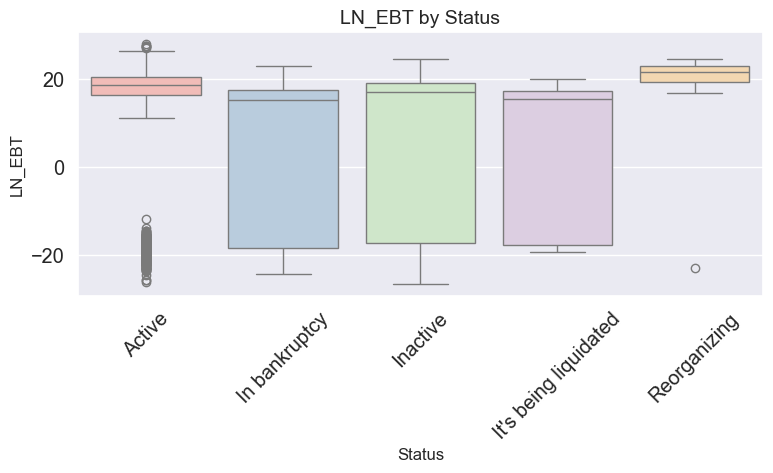

In [46]:
bivariate_boxplot(Bank_data, cat_col='Status', num_col='LN_EBT')


#### Bivariate Analysis: `LN_EBT` by `Status`

The boxplot above compares the distribution of `LN_EBT` (log-transformed Earnings Before Tax) across different bank statuses.

**Key Observations:**

- **Active banks** show a **bimodal distribution**: while the majority have high positive earnings, a distinct group shows very negative log values indicative of substantial losses.
- **Reorganizing banks** have the **most consistent and positive earnings**, with the highest median and the narrowest interquartile range, suggesting well-regulated or strategically positioned entities during the restructuring process.
- Banks **In bankruptcy**, **Inactive**, and **Being liquidated** all show wider spreads and **centered near or below zero**, indicating little to no profitability or frequent losses.
- The **variance in negative earnings** is especially pronounced among **bankrupt** and **inactive** institutions.

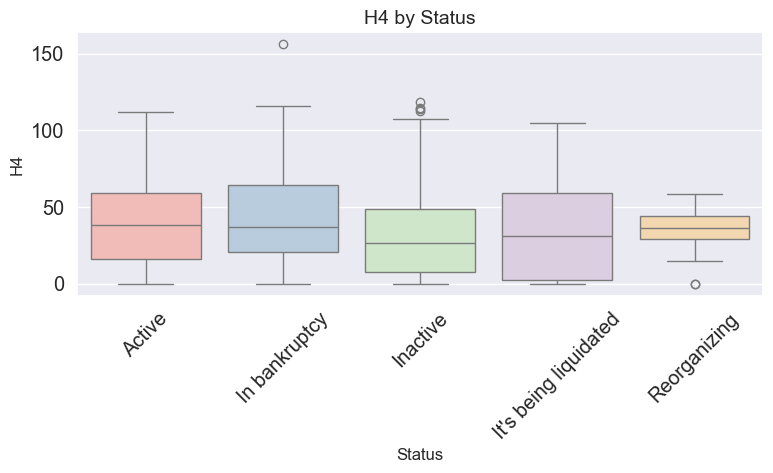

In [47]:
bivariate_boxplot(Bank_data, cat_col='Status', num_col='H4')


#### Bivariate Analysis: `H4` by `Status`

The boxplot above illustrates the distribution of the `H4` variable across various bank status categories.

**Key Observations:**

- **All status groups** show substantial spread in `H4`, with high variability and numerous outliers—particularly among **Inactive** and **In bankruptcy** banks.
- **In bankruptcy** banks display the highest median and widest interquartile range, suggesting more aggressive or volatile financial practices.
- **Reorganizing banks** show a relatively **narrow and lower distribution**, possibly due to regulatory constraints or conservatism during restructuring.
- **Active and Liquidated banks** display moderate `H4` levels with wider spread but fewer extreme outliers.

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def bivariate_boxplot_by_hedge_indicator(df, num_col, palette='Pastel1'):
    """
    Draws a boxplot comparing a numerical variable with the 'Hedge_indicator' column (as categorical).

    Parameters:
    df (DataFrame): The input DataFrame.
    num_col (str): Numerical column name (e.g., 'ROE').
    palette (str): Seaborn color palette for the plot.
    """
    if 'Hedge_indicator' not in df.columns or num_col not in df.columns:
        print(f"Error: 'Hedge_indicator' or '{num_col}' not found in the DataFrame.")
        return

    if not pd.api.types.is_numeric_dtype(df[num_col]):
        print(f"Error: '{num_col}' is not a numeric column.")
        return

    # Create a temporary copy to avoid modifying original data
    temp_df = df.copy()
    temp_df['Hedge_str'] = temp_df['Hedge_indicator'].astype(str)

    plt.figure(figsize=(8, 5))
    sns.boxplot(x='Hedge_str', y=num_col, data=temp_df, palette=palette)
    plt.title(f'{num_col} by Hedge Indicator', fontsize=14)
    plt.xlabel('Hedge Indicator (0 = No, 1 = Yes)', fontsize=12)
    plt.ylabel(num_col, fontsize=12)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


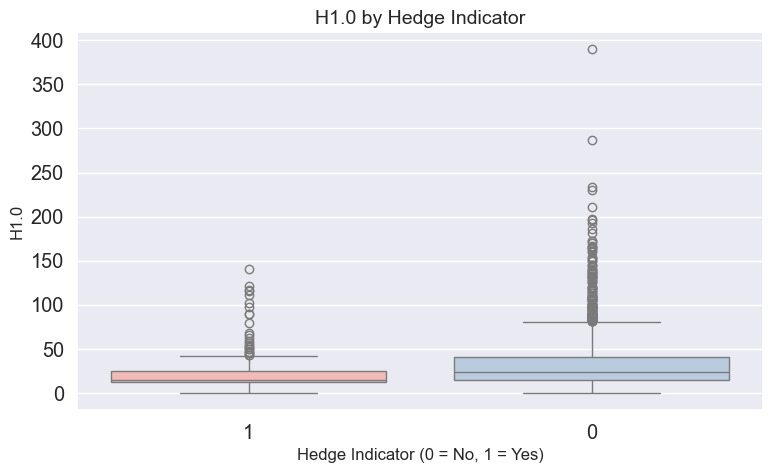

In [49]:
bivariate_boxplot_by_hedge_indicator(Bank_data, num_col='Н1.0')


#### Bivariate Analysis: `H1.0` by `Hedge Indicator`

This boxplot compares the distribution of `H1.0` values between banks that **do not hedge (0)** and those that **use interest rate swap hedging (1)**, as defined by the `Hedge_indicator`.

**Key Observations:**

- Banks that **do not hedge (Hedge Indicator = 0)** show a **higher median** and a much wider spread in `H1.0` values, with numerous extreme outliers.
- In contrast, **hedging banks (Hedge Indicator = 1)** have **lower and more concentrated `H1.0` values**, with a tighter interquartile range and fewer extreme values.
- Outliers are more prominent in the non-hedging group, especially at the upper tail, indicating that some banks without hedging still maintain high `H1.0` levels.


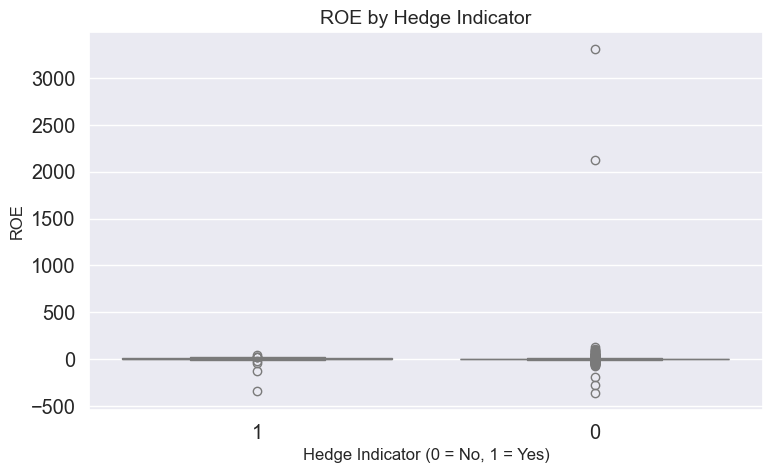

In [50]:
bivariate_boxplot_by_hedge_indicator(Bank_data, num_col='ROE')


#### Bivariate Analysis: `ROE` by `Hedge Indicator`

This plot examines the relationship between **Return on Equity (ROE)** and the binary `Hedge_indicator` variable, which denotes whether a bank adopts swap hedging (`1`) or not (`0`).

**Key Observations:**

- Both hedging and non-hedging banks exhibit a **wide spread in ROE values**, with many extreme outliers, particularly in the non-hedging group.
- The **median ROE** appears slightly higher for **hedging banks**, though the difference is not visually dramatic.
- The **presence of extreme outliers** some exceeding 2000 and 3000 suggests significant volatility or reporting anomalies that could distort modeling efforts if not handled.


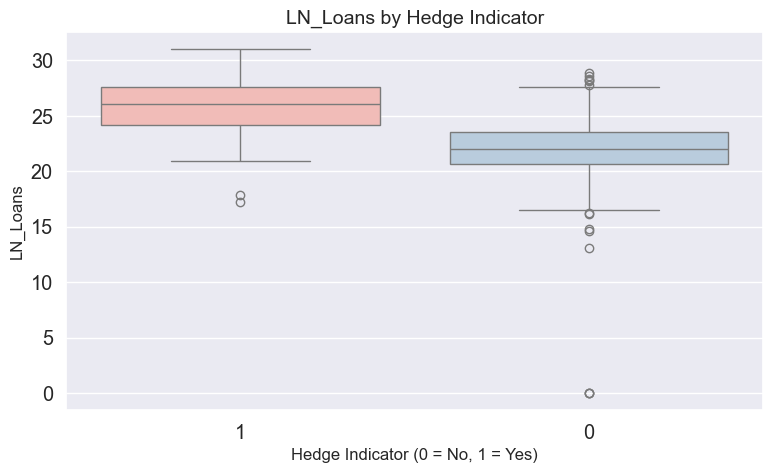

In [51]:
bivariate_boxplot_by_hedge_indicator(Bank_data, num_col='LN_Loans')


#### Bivariate Analysis: `LN_Loans` by `Hedge Indicator`

This boxplot explores how the **log-transformed loan volume (`LN_Loans`)** differs between banks that do and do not employ interest rate swap hedging (`Hedge_indicator` = 1 and 0 respectively).

**Key Observations:**

- **Hedging banks** (`Hedge_indicator = 1`) exhibit **higher median loan volumes** than non-hedging banks.
- The **interquartile range (IQR)** for hedging banks is also **tighter**, suggesting more consistency in loan size among these institutions.
- Non-hedging banks show a wider spread and a **larger number of lower-end outliers**, with some having exceptionally low loan volumes (e.g., near 0).
- The upper bounds for both groups are somewhat similar, but hedging banks clearly concentrate in a higher log-loan band.

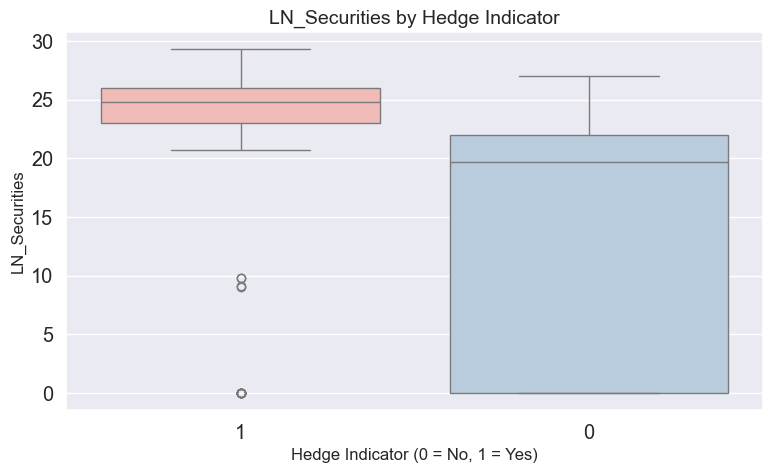

In [52]:
bivariate_boxplot_by_hedge_indicator(Bank_data, num_col='LN_Securities')


#### Bivariate Analysis: `LN_Securities` by `Hedge Indicator`

This boxplot compares the distribution of **log-transformed securities holdings (`LN_Securities`)** between banks that hedge interest rate risk (`Hedge_indicator = 1`) and those that do not (`Hedge_indicator = 0`).

**Key Observations:**

- **Hedging banks** (`Hedge_indicator = 1`) show **consistently higher median securities holdings** and a **tighter interquartile range (IQR)** compared to non-hedging banks.
- Non-hedging banks (`Hedge_indicator = 0`) have a wider spread, with several banks reporting **zero or near-zero securities**, as shown by the presence of a substantial lower tail.
- The **upper bounds** are roughly similar across both categories, but the **bulk of values** for hedging banks lies in a significantly **higher range**.

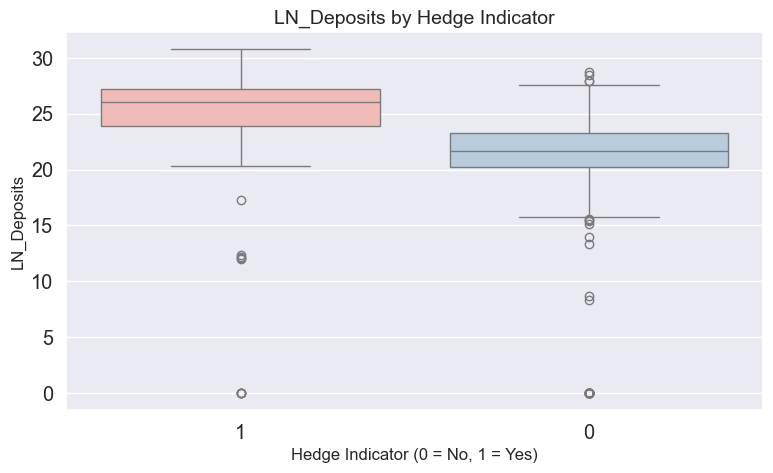

In [53]:
bivariate_boxplot_by_hedge_indicator(Bank_data, num_col='LN_Deposits')


#### Bivariate Analysis: `LN_Deposits` by `Hedge Indicator`

This boxplot illustrates the distribution of **log-transformed total deposits (`LN_Deposits`)** for banks that do (`Hedge_indicator = 1`) and do not (`Hedge_indicator = 0`) engage in hedging interest rate risk.

**Key Observations:**

- Banks that hedge (`Hedge_indicator = 1`) show a **higher median** and a **tighter interquartile range (IQR)** compared to non-hedging banks.
- Non-hedging banks have a **wider spread** in deposit levels, with several observations on the lower end and more visible outliers.
- The **upper quartiles** between the two groups are relatively similar, but the **entire distribution** for hedging banks is **shifted upward**.

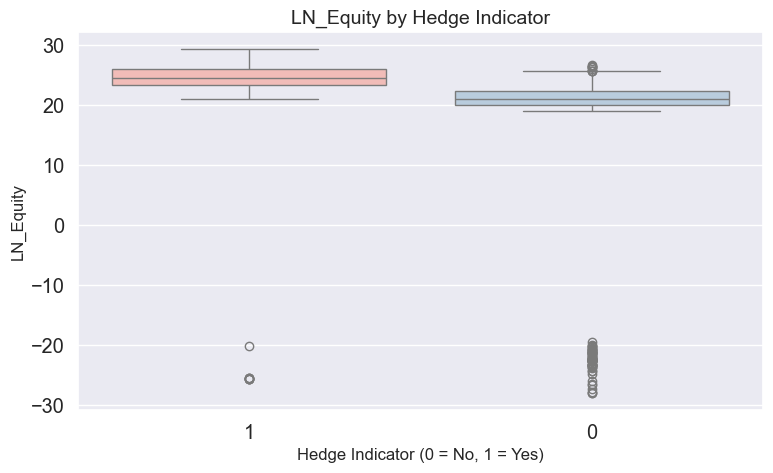

In [54]:
bivariate_boxplot_by_hedge_indicator(Bank_data, num_col='LN_Equity')


#### Bivariate Analysis: `LN_Equity` by `Hedge Indicator`

The boxplot compares the distribution of **log-transformed equity (`LN_Equity`)** between banks that hedge interest rate risk (`Hedge_indicator = 1`) and those that do not (`Hedge_indicator = 0`).

**Key Observations:**

- **Hedging banks** (`Hedge_indicator = 1`) show a **higher median and tighter interquartile range** in equity values.
- **Non-hedging banks** exhibit more **variability and a wider range** in equity, with several extreme negative outliers.
- The lower tail of the non-hedging group includes significantly negative log-equity values, which may suggest financial instability or reporting anomalies.

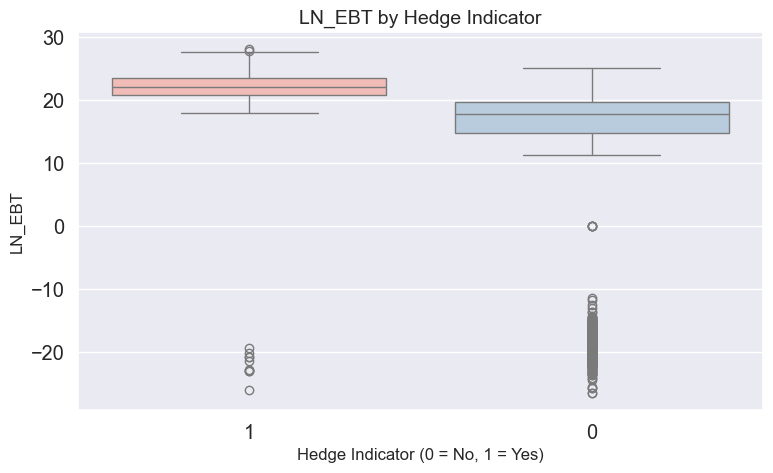

In [55]:
bivariate_boxplot_by_hedge_indicator(Bank_data, num_col='LN_EBT')


#### Bivariate Analysis: `LN_EBT` by `Hedge Indicator`

This boxplot visualizes the distribution of **log-transformed Earnings Before Tax (EBT)** across banks that do and do not hedge their interest rate risk.

**Key Observations:**

- **Hedging banks** (`Hedge_indicator = 1`) have:
  - A **higher median `LN_EBT`**, suggesting stronger pre-tax profitability.
  - A **more compact interquartile range**, indicating consistent earnings performance.
  - Fewer and less extreme negative outliers compared to non-hedging banks.

- **Non-hedging banks** (`Hedge_indicator = 0`) display:
  - **Lower median earnings** and a wider spread.
  - A **large concentration of negative outliers**, which indicates significant losses in several banks.



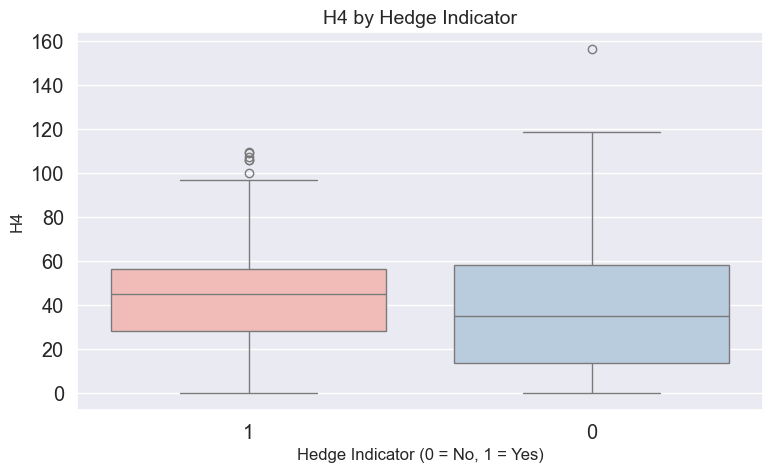

In [56]:
bivariate_boxplot_by_hedge_indicator(Bank_data, num_col='H4')


#### Bivariate Analysis: `H4` by `Hedge Indicator`

This boxplot illustrates the distribution of the `H4` variable across banks based on whether they hedge (`Hedge Indicator = 1`) or not (`Hedge Indicator = 0`).

**Key Observations:**

- **Non-hedging banks** (`Hedge Indicator = 0`) show:
  - A **wider spread** in `H4` values, indicating greater variability across banks.
  - **Higher maximum values and more extreme outliers**, suggesting that a few banks without hedging experience large `H4` values.
  - A **lower median** compared to hedging banks.

- **Hedging banks** (`Hedge Indicator = 1`) demonstrate:
  - A **more concentrated distribution**, implying greater consistency.
  - A **higher median H4**, indicating better average performance or stability.
  - **Fewer extreme outliers**.

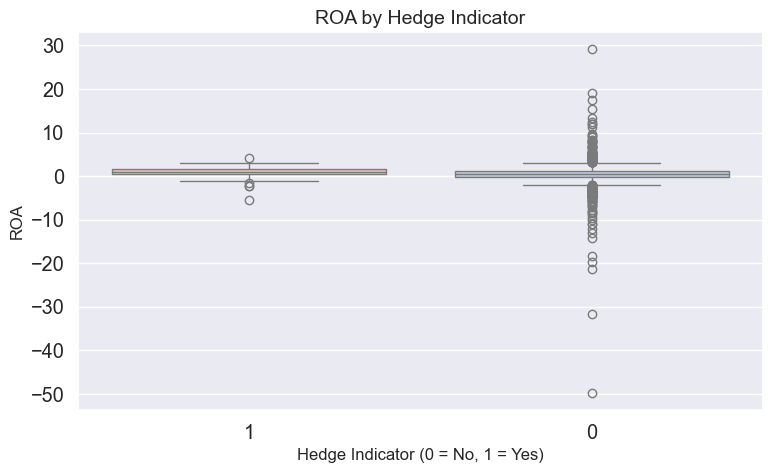

In [57]:
bivariate_boxplot_by_hedge_indicator(Bank_data, num_col='ROA')


#### Bivariate Analysis: `ROA` by `Hedge Indicator`

This boxplot visualizes the distribution of Return on Assets (`ROA`) across banks based on whether they hedge (`Hedge Indicator = 1`) or not (`Hedge Indicator = 0`).

**Key Observations:**

- **Hedging banks (Hedge Indicator = 1):**
  - Show a **narrower interquartile range**, suggesting more consistent and stable ROA values.
  - Have **fewer extreme outliers**, indicating reduced volatility in asset returns.
  - The **median ROA** is slightly higher and more centrally concentrated around positive values.

- **Non-hedging banks (Hedge Indicator = 0):**
  - Display a **much wider spread**, with significant positive and negative outliers.
  - Include **extreme negative values** (e.g., ROA < -40%), highlighting potential high-risk or underperforming institutions.
  - Despite many banks clustering near the median, the presence of outliers increases variability and risk.


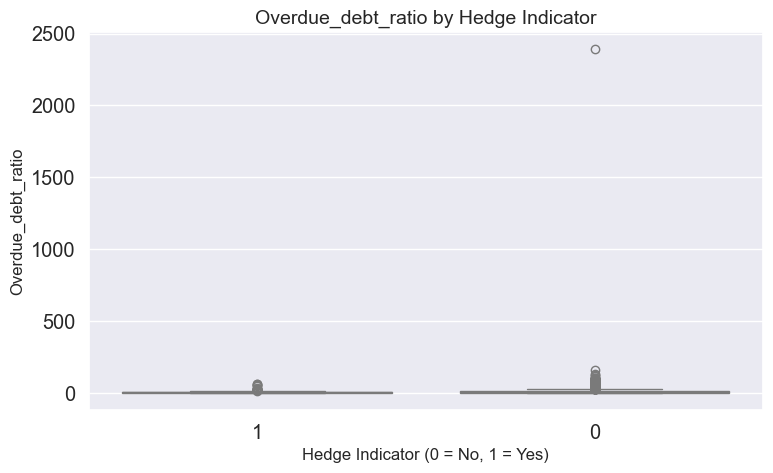

In [58]:
bivariate_boxplot_by_hedge_indicator(Bank_data, num_col='Overdue_debt_ratio')


#### Bivariate Analysis: `Overdue_debt_ratio` by `Hedge Indicator`

This boxplot compares the distribution of the overdue debt ratio between banks that hedge (Hedge Indicator = 1) and those that do not (Hedge Indicator = 0).

**Key Observations:**

- **Non-hedging banks (Hedge Indicator = 0):**
  - Exhibit a **wider spread and more extreme outliers**, with overdue debt ratios reaching values well above **2000%**.
  - The distribution is **highly right-skewed**, indicating that some banks without hedging practices have extremely high overdue liabilities.
  - The presence of extreme outliers significantly inflates the visual range, making typical values harder to distinguish.

- **Hedging banks (Hedge Indicator = 1):**
  - Show a **more compact and lower range of overdue debt ratios**.
  - There are **fewer and less extreme outliers**, suggesting better debt management.
  - The interquartile range is significantly tighter, indicating **consistently lower overdue risk**.

## Data Preparation

### 1. Handling Null Values

In [59]:
# Count of missing values
missing_count = Bank_data.isnull().sum()

# Percentage of missing values
missing_percent = (missing_count / len(Bank_data)) * 100

# Combine into one DataFrame for display
missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_percent.round(2)
})

# Show only columns with at least one missing value
missing_summary = missing_summary[missing_summary['Missing Count'] > 0]

# Display
print(missing_summary)


                    Missing Count  Missing %
Н1.0                           22       0.93
ROE                             5       0.21
LN_Equity                       7       0.30
H4                            361      15.34
Overdue_debt_ratio             22       0.93


In [60]:
# Use median to fill missing values — less sensitive to outliers
Bank_data['Н1.0'] = Bank_data['Н1.0'].fillna(Bank_data['Н1.0'].median())
Bank_data['ROE'] = Bank_data['ROE'].fillna(Bank_data['ROE'].median())
Bank_data['LN_Equity'] = Bank_data['LN_Equity'].fillna(Bank_data['LN_Equity'].median())
Bank_data['Overdue_debt_ratio'] = Bank_data['Overdue_debt_ratio'].fillna(Bank_data['Overdue_debt_ratio'].median())


### Handling Missing Values with Median Imputation

To ensure data completeness and maintain model robustness, we address missing values in key numerical variables using **median imputation**. This approach is particularly effective when the data contains **outliers**, as the median is a more **robust measure of central tendency** compared to the mean.

The following variables were imputed with their respective median values:

- `Н1.0`
- `ROE`
- `LN_Equity`
- `Overdue_debt_ratio`

In [61]:
from sklearn.impute import KNNImputer

# Step 1: Selecting only float columns (those with missing values)
knn_cols = Bank_data.select_dtypes(include='float64').columns

# Step 2: Initialize the imputer
knn_imputer = KNNImputer(n_neighbors=5)

# Step 3: Apply KNN imputation to float columns
Bank_data[knn_cols] = knn_imputer.fit_transform(Bank_data[knn_cols])


### KNN Imputation for `H4`

Since the `H4` variable has approximately **15% missing values**, we apply **K-Nearest Neighbors (KNN) imputation** to estimate its missing entries. This technique uses similarities between rows based on all numeric columns.

In [62]:
# Count of missing values
missing_count = Bank_data.isnull().sum()

# Percentage of missing values
missing_percent = (missing_count / len(Bank_data)) * 100

# Combine into one DataFrame for display
missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_percent.round(2)
})

# Show only columns with at least one missing value
missing_summary = missing_summary[missing_summary['Missing Count'] > 0]

# Display
print(missing_summary)


Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


Hence, we took care of all the Null values

### 2. Forward selection

In [63]:
!pip install mlxtend

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
import pandas as pd

# STEP 1: Prepare the data
# Drop the target and ID column
X = Bank_data.drop(columns=['Hedge_indicator', 'Bank'])
y = Bank_data['Hedge_indicator']

# STEP 2: One-hot encode all categorical variables (e.g., 'Status')
X_encoded = pd.get_dummies(X, drop_first=True)

# STEP 3: Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42, stratify=y
)

# STEP 4: Initialize logistic regression model
lr = LogisticRegression(max_iter=1000, solver='liblinear')

# STEP 5: Perform forward selection
sfs = SFS(estimator=lr,
          k_features=6,
          forward=True,
          floating=False,
          scoring='f1',
          cv=5,
          verbose=2,
          n_jobs=-1)

sfs = sfs.fit(X_train, y_train)

# STEP 6: Output selected features
selected_indices = sfs.k_feature_idx_
selected_columns = [X_encoded.columns[i] for i in selected_indices]

print("\n✅ Final Selected Features After Forward Selection:")
print(selected_columns)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.


[Parallel(n_jobs=-1)]: Done   8 out of  15 | elapsed:    2.8s remaining:    2.5s
[Parallel(n_jobs=-1)]: Done  15 out of  15 | elapsed:    3.0s finished

[2026-06-08 20:13:33] Features: 1/6 -- score: 0.0[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.


[Parallel(n_jobs=-1)]: Done   7 out of  14 | elapsed:    1.0s remaining:    1.0s
[Parallel(n_jobs=-1)]: Done  14 out of  14 | elapsed:    1.0s finished

[2026-06-08 20:13:34] Features: 2/6 -- score: 0.46099473935915836[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 out of  13 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  13 out of  13 | elapsed:    0.0s finished

[2026-06-08 20:13:34] Features: 3/6 -- score: 0.5174142000270592[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   7 out of  12 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  12 out of  12 | elapsed:    0.0s finished

[2026-06-08 20:13:34] Features: 4/6 -- score: 0.5246037425107193[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.



✅ Final Selected Features After Forward Selection:
['Year', 'LN_Loans', 'LN_Securities', 'ROA', 'Overdue_debt_ratio', 'Status_Reorganizing']


[Parallel(n_jobs=-1)]: Done   6 out of  11 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  11 out of  11 | elapsed:    0.0s finished

[2026-06-08 20:13:34] Features: 5/6 -- score: 0.5345097619638624[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of  10 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    0.0s finished

[2026-06-08 20:13:34] Features: 6/6 -- score: 0.5403683478224482

### Forward Feature Selection Using Logistic Regression

To identify the most predictive features for forecasting swap-hedging adoption (`Hedge_indicator`), we employed **forward stepwise selection** using a logistic regression model. This technique starts with an empty model and adds features one at a time, choosing the one that improves the model's F1-score the most at each step.

The steps followed were:

1. **Feature Preparation**:
   - Dropped the target variable `Hedge_indicator` and non-informative ID column `Bank`.
   - Applied one-hot encoding to convert categorical variables (e.g., `Status`) into numeric form using `pd.get_dummies()`.

2. **Train-Test Split**:
   - Split the dataset into training (70%) and testing (30%) sets using stratified sampling to preserve class balance.

3. **Model Configuration**:
   - Logistic Regression with `liblinear` solver was used for its suitability with smaller datasets and binary classification.
   - Forward selection was carried out using **5-fold cross-validation** and evaluated using **F1-score**, which balances precision and recall.

4. **Selection Output**:
   - The algorithm iteratively added the best-performing features until six variables were selected.


## Prepped Data Review

In this section we will do the prepeed data review to the selected columns **'Year', 'LN_Loans', 'LN_Securities', 'ROA', 'Overdue_debt_ratio' and 'Status_Reorganizing'**

As we have already taken care of Null values of **Overdue_debt_ratio** column we are doing the univariate analysis of only **Overdue_debt_ratio** variable.


Summary statistics for 'Overdue_debt_ratio':
count    2354.000000
mean       12.170047
std        52.053393
min         0.000000
25%         1.972500
50%         5.240000
75%        11.370000
max      2390.450000
Name: Overdue_debt_ratio, dtype: float64


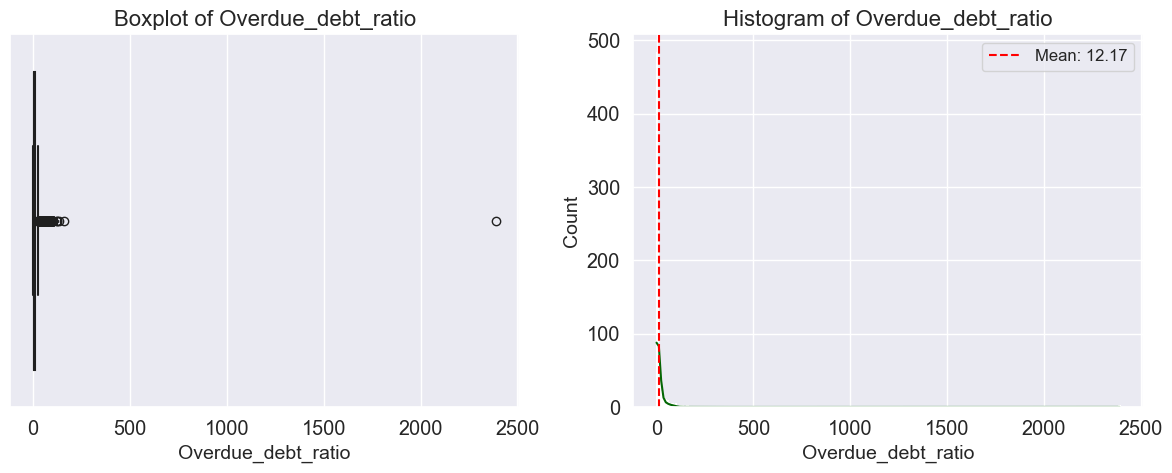

In [65]:
univariate_analysis(Bank_data, 'Overdue_debt_ratio')

### Univariate Analysis: Overdue_debt_ratio

The variable `Overdue_debt_ratio` represents the ratio of overdue debt held by banks. This is a critical indicator of credit risk and financial distress.

#### Summary Statistics:
- **Count**: 2,354
- **Mean**: 12.17
- **Median (50%)**: 5.24
- **Standard Deviation**: 52.05
- **Min**: 0.00
- **Max**: 2,390.45
- **25th Percentile (Q1)**: 1.97
- **75th Percentile (Q3)**: 11.37

#### Key Observations:
- The **boxplot** reveals an extremely right-skewed distribution with multiple high-end outliers. Most of the data lies within a very narrow range, but a few extreme values greatly distort the scale.
- The **histogram** confirms this right skew, where the vast majority of observations fall below 50, and only a handful exceed several hundred.
- The **mean (12.17)** is substantially greater than the **median (5.24)**, further emphasizing the impact of outliers.
- These patterns suggest that while most banks maintain low overdue debt ratios, a few institutions face disproportionately high credit risk.

### Bivariate Analysis

#### 1. Heatmap between Numerical Variables

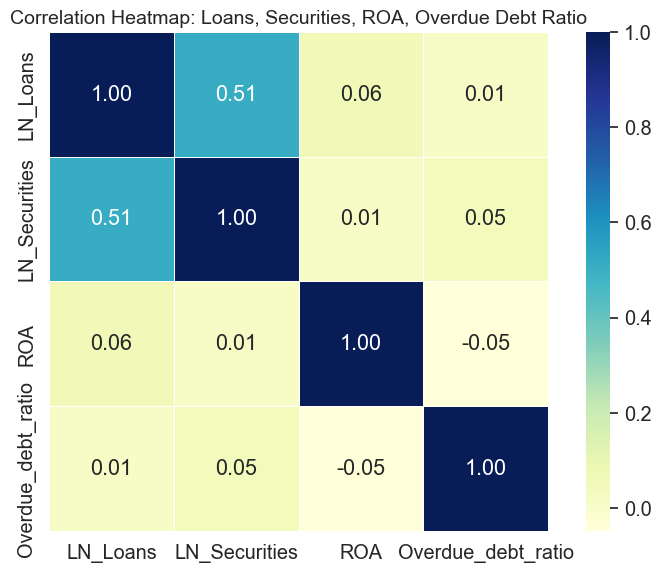

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the specific columns
selected_cols = ['LN_Loans', 'LN_Securities', 'ROA', 'Overdue_debt_ratio']

# Compute correlation matrix for selected columns
correlation_matrix = Bank_data[selected_cols].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='YlGnBu', linewidths=0.5, square=True)
plt.title("Correlation Heatmap: Loans, Securities, ROA, Overdue Debt Ratio", fontsize=14)
plt.tight_layout()
plt.show()


### Correlation Heatmap: LN_Loans, LN_Securities, ROA, Overdue_debt_ratio

The heatmap below illustrates the pairwise Pearson correlation between four selected financial indicators:

- **LN_Loans** and **LN_Securities** show a moderate positive correlation (0.51), indicating that banks with higher loan volumes often hold more securities.
- **ROA** and **Overdue_debt_ratio** have very weak or negligible correlations with the other features, suggesting limited linear relationships.
- All variables show low multicollinearity, making them suitable for inclusion in modeling tasks without major redundancy.

This analysis helps validate the use of these features together in predictive models.


### Bivaraite analysis between categorical varaible ( Year vs Status_Reorganizing)

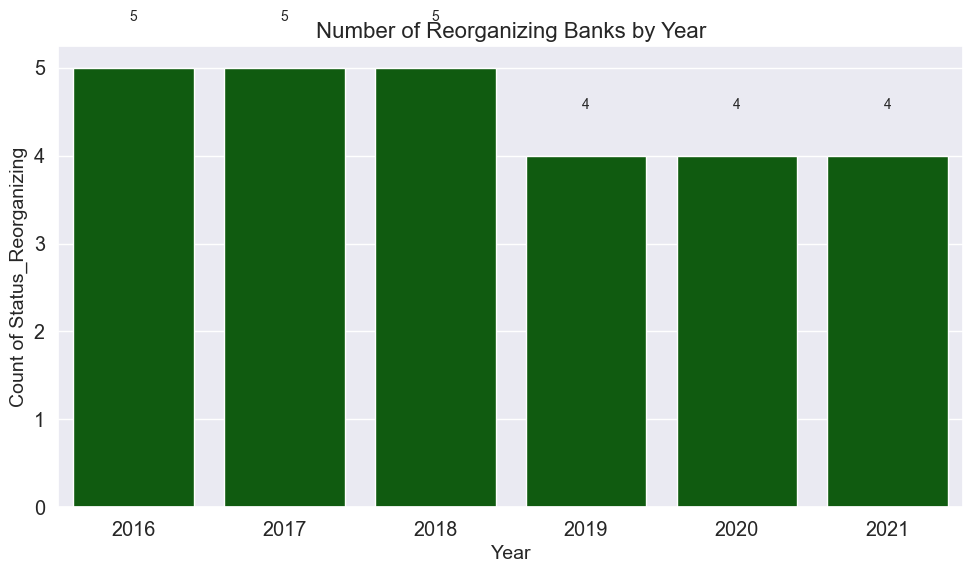

In [67]:
# Copy and prepare the data
bank_copy = Bank_data.copy()
bank_copy['Year_str'] = bank_copy['Year'].astype(str)

# Create the one-hot encoded status column
if 'Status_Reorganizing' not in bank_copy.columns:
    status_dummies = pd.get_dummies(bank_copy['Status'], prefix='Status', drop_first=True)
    bank_copy = pd.concat([bank_copy, status_dummies], axis=1)

# Group by year and sum the reorganizing status
year_reorg_group = bank_copy.groupby('Year_str')['Status_Reorganizing'].sum().reset_index()

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Year_str', y='Status_Reorganizing', data=year_reorg_group, color='#036704')

# Add data labels
for index, row in year_reorg_group.iterrows():
    plt.text(index, row['Status_Reorganizing'] + 0.5, int(row['Status_Reorganizing']),
             ha='center', va='bottom', fontsize=10)

# Titles and labels
plt.title("Number of Reorganizing Banks by Year", fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Count of Status_Reorganizing", fontsize=14)
plt.tight_layout()
plt.show()


### Bivariate Analysis: Year vs Status_Reorganizing

The bar chart below displays the yearly count of banks that were in the "Reorganizing" status between 2016 and 2021.

- From 2016 to 2018, exactly 5 banks were classified as "Reorganizing" each year.
- A slight decrease occurred from 2019 onwards, with only 4 such banks annually.
- This trend suggests a relatively stable but limited number of reorganizing banks over the observed period.

This insight supports the idea that while reorganizations were consistently present, they remained a minority event in the banking sector and could reflect regulatory or strategic restructuring decisions.


### Bivaraite analysis 'Year' vs Numerical selected varaibles

In [68]:
def bivariate_boxplot_by_year(df, num_col, palette='Pastel1'):
    """
    Draws a boxplot comparing a numerical variable with the 'Year' column.

    Parameters:
    df (DataFrame): The input DataFrame.
    num_col (str): Numerical column name (e.g., 'ROE').
    palette (str): Seaborn color palette for the plot.
    """
    if 'Year' not in df.columns or num_col not in df.columns:
        print(f"Error: 'Year' or '{num_col}' not found in the DataFrame.")
        return

    if not pd.api.types.is_numeric_dtype(df[num_col]):
        print(f"Error: '{num_col}' is not a numeric column.")
        return

    plt.figure(figsize=(8, 5))
    sns.boxplot(x='Year', y=num_col, data=df, palette=palette)
    plt.title(f'{num_col} by Year', fontsize=14)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel(num_col, fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


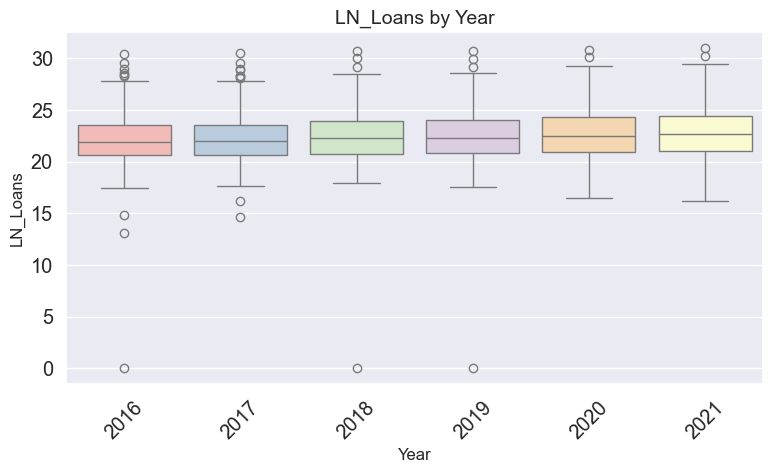

In [69]:
bivariate_boxplot_by_year(Bank_data, num_col='LN_Loans')

### Bivariate Analysis: LN_Loans by Year

The boxplot above shows the distribution of log-transformed loan volumes (`LN_Loans`) across reporting years from 2016 to 2021.

**Key Observations:**
- The median loan volume remains relatively stable across the years, with only slight variations.
- All years show a similar interquartile range (IQR), indicating consistent loan distribution over time.
- A few extreme outliers (including zero values) persist in all years, suggesting some banks maintain unusually small loan portfolios or are inactive.
- Overall, the volume of loans does not show a strong upward or downward trend across the 6-year period.

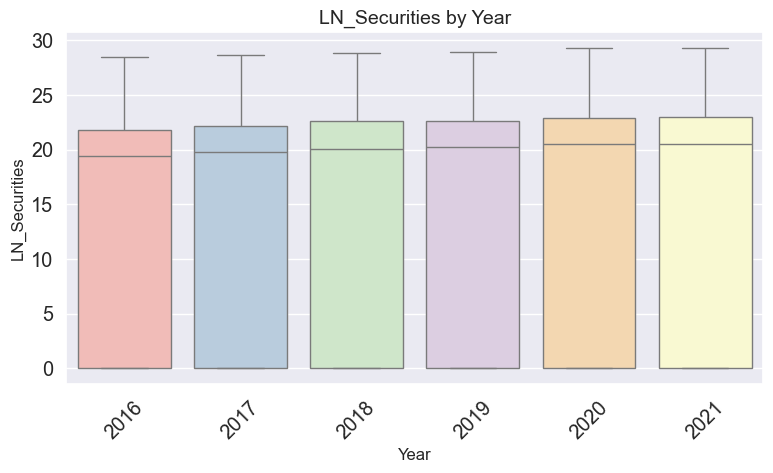

In [70]:
bivariate_boxplot_by_year(Bank_data, num_col='LN_Securities')

### Bivariate Analysis: LN_Securities by Year

The boxplot illustrates the yearly distribution of log-transformed securities holdings (`LN_Securities`) from 2016 to 2021.

**Key Observations:**
- The median value of securities holdings shows a mild increasing trend, especially after 2017.
- Interquartile ranges (IQRs) are consistently wide, indicating variability in bank investment behavior across all years.
- The spread across years remains relatively similar, suggesting that market-wide shifts in securities portfolios were modest.
- Presence of zero or near-zero values across all years implies some banks maintained minimal or no securities, possibly reflecting risk aversion or liquidation.


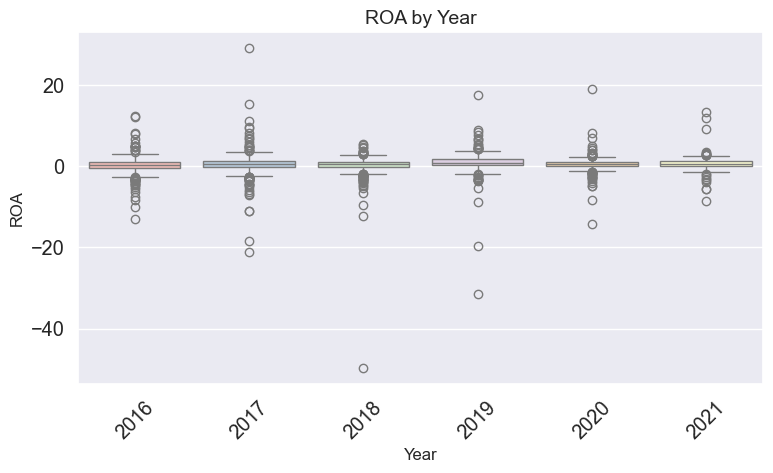

In [71]:
bivariate_boxplot_by_year(Bank_data, num_col='ROA')

### Bivariate Analysis: ROA by Year

The boxplot displays the distribution of Return on Assets (ROA) from 2016 to 2021.

**Key Observations:**
- Median ROA values remain relatively stable across years, centered near 0, indicating consistent profitability levels on average.
- All years exhibit a wide range of ROA values, with several extreme outliers—both positive and negative—highlighting variability in asset returns.
- Negative ROA outliers are more prominent, especially in 2018 and 2017, suggesting financial distress in a subset of banks during those years.
- The compact interquartile ranges (IQRs) reflect that most banks have tightly clustered ROA values, despite the long tails caused by outliers.


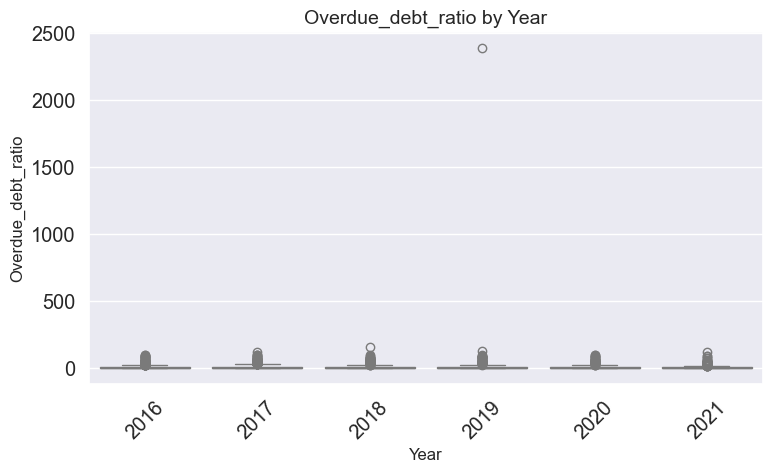

In [72]:
bivariate_boxplot_by_year(Bank_data, num_col='Overdue_debt_ratio')

### Bivariate Analysis: Overdue Debt Ratio by Year

The boxplot illustrates how the overdue debt ratio varies across the years 2016 to 2021.

**Key Observations:**
- Across all years, the distribution is heavily right-skewed due to extreme outliers, particularly in 2018 and 2019 where values exceed 2000%.
- The median overdue debt ratios are relatively consistent and low, mostly below 10%, suggesting that typical banks maintain manageable levels of overdue liabilities.
- The interquartile ranges (IQRs) are narrow for each year, confirming that most banks cluster around low overdue debt ratios.
- Outliers dominate the plot scale, especially in earlier years, potentially impacting model performance or interpretability if not properly handled or transformed.


Now we are done with the data prep review, Let's move forward with the Models section

## Machine Learning Models

In [73]:
from sklearn.model_selection import train_test_split

# Step 1: Base features including categorical 'Status' for encoding
base_features = ['Year', 'LN_Loans', 'LN_Securities', 'ROA', 'Overdue_debt_ratio', 'Status']
X_raw = Bank_data[base_features]

# Step 2: One-hot encode 'Status' to create 'Status_Reorganizing' and other dummies
X_encoded = pd.get_dummies(X_raw, columns=['Status'], drop_first=True)

# Step 3: Define final features after forward selection
selected_features = ['Year', 'LN_Loans', 'LN_Securities', 'ROA', 'Overdue_debt_ratio', 'Status_Reorganizing']
X = X_encoded[selected_features]

# Step 4: Define target variable
y = Bank_data['Hedge_indicator']

# Step 5: Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Step 6: Null error rate (majority class baseline)
majority_class_proportion = max(y_train.value_counts(normalize=True))
null_error_rate = 1 - majority_class_proportion

# Step 7: Print results
print(f" Null Error Rate (Training Set): {null_error_rate:.4f}")
print("Target Distribution in Training Set:")
print(y_train.value_counts(normalize=True))


 Null Error Rate (Training Set): 0.0801
Target Distribution in Training Set:
Hedge_indicator
0    0.919854
1    0.080146
Name: proportion, dtype: float64


### Train-Test Split and Null Error Rate Calculation

- We begin by selecting six key features identified through forward selection, including the `Status` variable.

- The `Status` categorical variable is one-hot encoded to generate a binary column for `'Status_Reorganizing'`.

- A stratified train-test split (70% training, 30% test) is performed to preserve the class distribution of the target variable `Hedge_indicator`.

- This same split (`X_train`, `X_test`, `y_train`, `y_test`) will be consistently used across all classification models built below to ensure fair model comparison.

- The **null error rate** is calculated to establish a baseline: it represents the error made by always predicting the majority class (i.e., no learning at all).


### 1. logistic regression

=== TRAIN METRICS ===
Accuracy (Train): 0.9435
F1 Score (Train): 0.5419
AUC (Train):      0.9048

Confusion Matrix (Train):
[[1499   16]
 [  77   55]]

Classification Report (Train):
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1515
           1       0.77      0.42      0.54       132

    accuracy                           0.94      1647
   macro avg       0.86      0.70      0.76      1647
weighted avg       0.94      0.94      0.94      1647



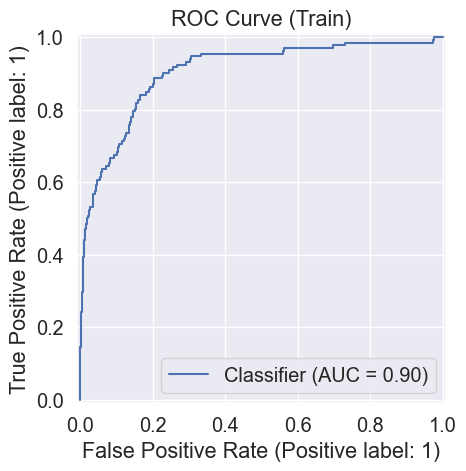

In [74]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    RocCurveDisplay
)

# --------------------------------------
# Initialize and fit Logistic Regression
# --------------------------------------
log_reg = LogisticRegression(max_iter=1000, solver='liblinear')
log_reg.fit(X_train, y_train)

# --------------------
# Predictions on TRAIN
# --------------------
y_train_pred = log_reg.predict(X_train)
y_train_prob = log_reg.predict_proba(X_train)[:, 1]

# Train Metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
train_auc = roc_auc_score(y_train, y_train_prob)

print("=== TRAIN METRICS ===")
print(f"Accuracy (Train): {train_accuracy:.4f}")
print(f"F1 Score (Train): {train_f1:.4f}")
print(f"AUC (Train):      {train_auc:.4f}\n")

# Confusion Matrix + Classification Report (Train)
print("Confusion Matrix (Train):")
print(confusion_matrix(y_train, y_train_pred))
print("\nClassification Report (Train):")
print(classification_report(y_train, y_train_pred))

# ROC Curve (Train)
RocCurveDisplay.from_predictions(y_train, y_train_prob)
plt.title("ROC Curve (Train)")
plt.show()


###  Logistic Regression – Model Evaluation on Training Set

**Performance Metrics on Training Data**

- **Accuracy**: `94.35%`  
- **F1 Score (Class 1 - Hedge Adoption)**: `0.5419`  
- **AUC (ROC Area Under Curve)**: `0.9048`  

These metrics suggest that the model fits the training data well, especially considering the high AUC score indicating excellent class separation capability.

---

#### **Confusion Matrix (Train)**

|                 | Predicted: 0 | Predicted: 1 |
|-----------------|--------------|--------------|
| **Actual: 0**   | 1499         | 16           |
| **Actual: 1**   | 77           | 55           |

The classifier successfully identified 55 of the 132 hedge-adopting banks (`Recall ≈ 42%`), with strong overall accuracy and very low false positive rate for the majority class.

---

#### **Classification Report (Train)**

- **Precision (Class 1)**: `0.77`  
- **Recall (Class 1)**: `0.42`  
- **F1 Score (Class 1)**: `0.54`  
- The model performs best on the majority class (Class 0), as expected given the class imbalance.

---

#### **ROC Curve**

The ROC curve shows a high area under the curve (AUC ≈ 0.90), confirming that the model is effective at distinguishing between hedging and non-hedging banks.

>  This model serves as a baseline benchmark for evaluating more complex models like Decision Trees, XGBoost, or Neural Networks in the upcoming sections.


### 2. Decision Trees

Fitting 5 folds for each of 36 candidates, totalling 180 fits


 Best Hyperparameters: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}

=== TRAIN METRICS ===
Train Accuracy: 0.9441

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1515
           1       0.73      0.48      0.58       132

    accuracy                           0.94      1647
   macro avg       0.84      0.73      0.77      1647
weighted avg       0.94      0.94      0.94      1647



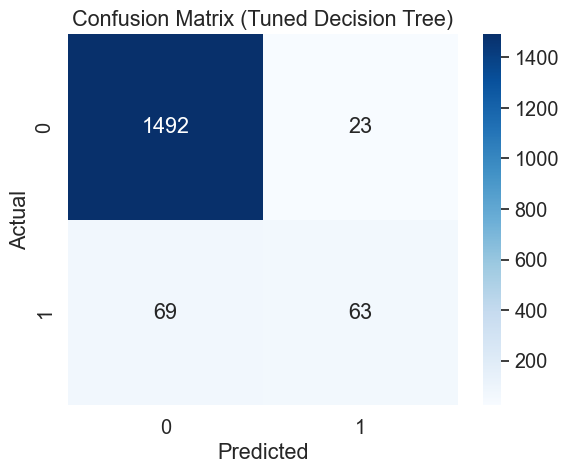

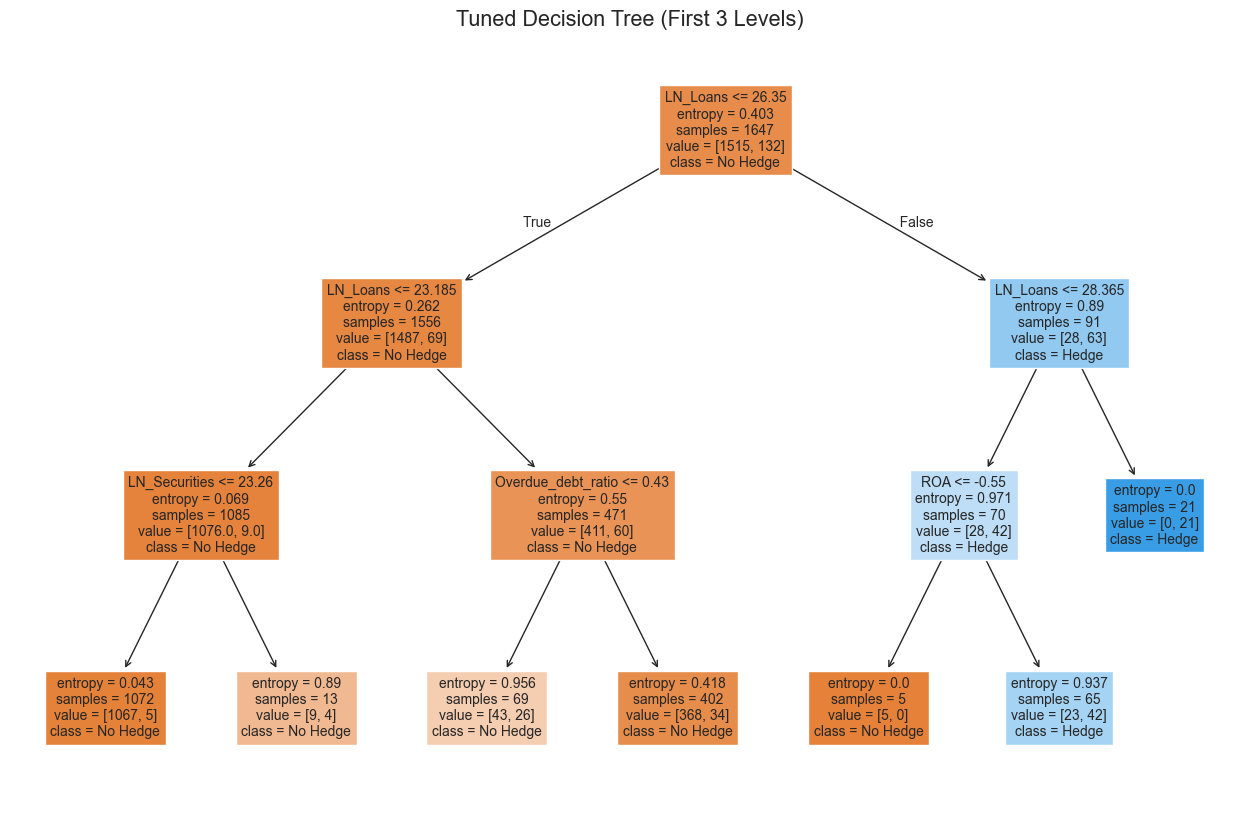

In [75]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --------------------------------------
# Grid Search: Hyperparameter Tuning
# --------------------------------------
param_grid = {
    'max_depth': [None, 3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

# Initialize base Decision Tree classifier
base_clf = DecisionTreeClassifier(criterion='entropy', random_state=47)

# GridSearchCV for tuning
grid_dt = GridSearchCV(
    estimator=base_clf,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

# Fit the model on training data using full selected feature set
grid_dt.fit(X_train, y_train)

# Get the best estimator
best_clf_dt = grid_dt.best_estimator_
print(" Best Hyperparameters:", grid_dt.best_params_)

# --------------------------------------
# Predictions and Evaluation on TRAIN set
# --------------------------------------
y_pred_train_dt = best_clf_dt.predict(X_train)

# Metrics
train_accuracy = accuracy_score(y_train, y_pred_train_dt)
print("\n=== TRAIN METRICS ===")
print(f"Train Accuracy: {train_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_train, y_pred_train_dt))

# Confusion Matrix
cm = confusion_matrix(y_train, y_pred_train_dt, labels=best_clf_dt.classes_)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_clf_dt.classes_, yticklabels=best_clf_dt.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Tuned Decision Tree)')
plt.tight_layout()
plt.show()

# --------------------------------------
# Plot the First 3 Levels of the Tree
# --------------------------------------
plt.figure(figsize=(16, 10))
plot_tree(
    best_clf_dt,
    feature_names=X_train.columns,
    class_names=['No Hedge', 'Hedge'],
    filled=True,
    max_depth=3,
    fontsize=10
)
plt.title('Tuned Decision Tree (First 3 Levels)')
plt.show()


## Decision Tree Classifier (Tuned) – Training Set Evaluation

This section documents the performance of a **Decision Tree Classifier** built using the features selected from forward selection and the previously defined train-test split.

### Model Tuning & Selection
- The Decision Tree model was tuned using **GridSearchCV** over a range of hyperparameters:
  - `max_depth`: [None, 3, 5, 10]
  - `min_samples_split`: [2, 5, 10]
  - `min_samples_leaf`: [1, 2, 5]
- The evaluation metric used for tuning was **F1 Macro**, and the model was validated using **5-fold cross-validation**.
- **Best Parameters Identified**: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}

### Training Set Performance
- **Accuracy**: 0.9441  
- **F1 Score (Class 1 - Hedge)**: 0.58  
- **Macro Average F1**: 0.77  
- These metrics indicate a reasonably good balance between precision and recall for both classes, despite a slightly lower recall for the minority class.

### Confusion Matrix
The matrix below shows the number of correct and incorrect predictions made by the model on the training set.

- **True Negatives (0 predicted as 0)**: 1492  
- **False Positives (0 predicted as 1)**: 23  
- **False Negatives (1 predicted as 0)**: 69  
- **True Positives (1 predicted as 1)**: 63  

>  Although the model shows high overall accuracy, the relatively higher number of false negatives suggests room for improvement in capturing the minority class (`Hedge_indicator = 1`).

### Decision Tree Visualization (Top 3 Levels)
The visualized tree helps interpret the decision-making logic of the classifier. Key insights include:

- The most important split is based on **LN_Loans**, followed by **LN_Securities**, **ROA**, and **Overdue_debt_ratio**.
- Leaf nodes represent class predictions (`No Hedge` or `Hedge`) based on the majority class within the node.

This interpretability makes the decision tree a valuable baseline model for understanding feature importance and classification thresholds.



### 3. XG Boost Model

In [76]:
# Install XGBoost if not already installed
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Fitting 5 folds for each of 8 candidates, totalling 40 fits


 Best XGBoost Hyperparameters: {'xgb__learning_rate': 0.1, 'xgb__max_depth': 5, 'xgb__n_estimators': 100}

=== TRAIN METRICS ===
Train Accuracy: 0.9903

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1515
           1       0.99      0.89      0.94       132

    accuracy                           0.99      1647
   macro avg       0.99      0.94      0.97      1647
weighted avg       0.99      0.99      0.99      1647



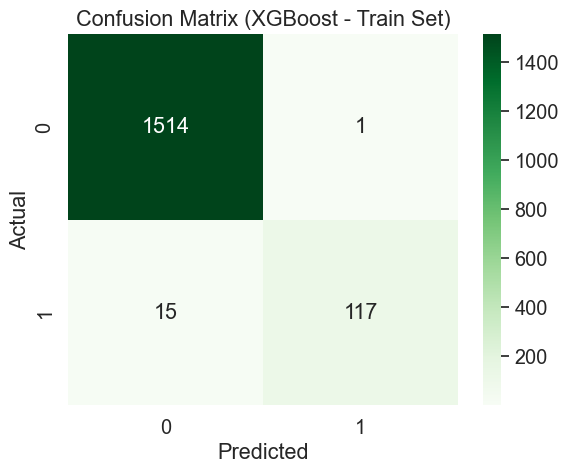

In [77]:
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------------------
# Encode y_train for compatibility with XGBoost
# ----------------------------------------
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

# ----------------------------------------
# Define XGBoost pipeline
# ----------------------------------------
xgb_pipeline = Pipeline([
    ('xgb', xgb.XGBClassifier(eval_metric='logloss', random_state=47))
])

# ----------------------------------------
# Hyperparameter tuning
# ----------------------------------------
param_grid_xgb = {
    'xgb__n_estimators': [100, 200],
    'xgb__learning_rate': [0.01, 0.1],
    'xgb__max_depth': [3, 5]
}

grid_xgb = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid_xgb,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

# ----------------------------------------
# Fit the model on the existing training data
# ----------------------------------------
grid_xgb.fit(X_train, y_train_encoded)
print(" Best XGBoost Hyperparameters:", grid_xgb.best_params_)

# ----------------------------------------
# Predict on training set
# ----------------------------------------
y_pred_encoded = grid_xgb.predict(X_train)
y_pred = le.inverse_transform(y_pred_encoded)

# ----------------------------------------
# Evaluation metrics
# ----------------------------------------
train_accuracy = accuracy_score(y_train, y_pred)
print(f"\n=== TRAIN METRICS ===")
print(f"Train Accuracy: {train_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_train, y_pred))

# ----------------------------------------
# Confusion Matrix
# ----------------------------------------
cm = confusion_matrix(y_train, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (XGBoost - Train Set)')
plt.tight_layout()
plt.show()


## XGBoost Classifier: Model Training and Evaluation (Train Set)

###  Best Hyperparameters Identified:
- `learning_rate`: 0.1  
- `max_depth`: 5  
- `n_estimators`: 100

---

###  Evaluation on Training Set

**Train Accuracy:** 0.9903

**Classification Report:**
          precision    recall  f1-score   support

       0       0.99      1.00      0.99      1515
       1       0.99      0.89      0.94       132

accuracy                           0.99      1647


The XGBoost model achieved excellent results on the training set, with both classes (Hedge and No Hedge) showing high precision and recall. The relatively high **recall of 0.89** for the positive class (1 = Hedge) demonstrates the model’s strong ability to correctly identify hedge cases.

---

###  Confusion Matrix (Train Set)

The confusion matrix below shows the breakdown of predictions:

- **1514 true negatives** (class 0 correctly predicted)
- **117 true positives** (class 1 correctly predicted)
- **1 false positive**
- **15 false negatives**

## 4. Neural Networks

 Training Neural Network (200 epochs, SiLU)…
Epoch 1/200


 1/42 ━━━━━━━━━━━━━━━━━━━━ 20s 511ms/step - accuracy: 0.3750 - loss: 0.7535

42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8967 - loss: 0.3207 - val_accuracy: 0.9212 - val_loss: 0.2036


Epoch 2/200


 1/42 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9062 - loss: 0.1904

...

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9772 - loss: 0.0558 - val_accuracy: 0.9152 - val_loss: 0.4073



 TRAIN Accuracy: 0.9684 | Loss: 0.1200
 1/52 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step

52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step



Confusion Matrix (Train):


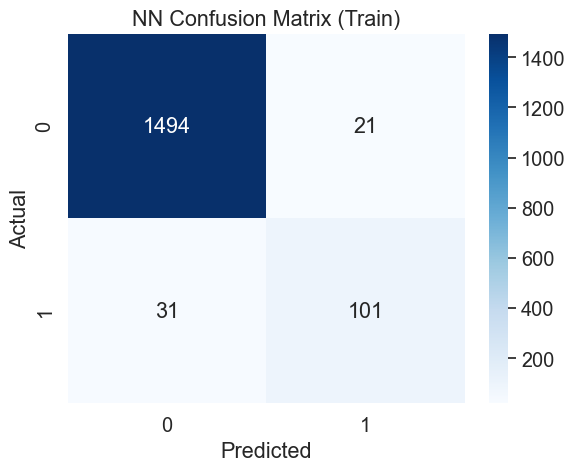


Classification Report (Train):
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1515
           1       0.83      0.77      0.80       132

    accuracy                           0.97      1647
   macro avg       0.90      0.88      0.89      1647
weighted avg       0.97      0.97      0.97      1647



In [78]:
# ----------------------------
# Neural Network Classifier
# (Reusing the existing X_train, X_test, y_train, y_test)
# ----------------------------

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- STEP 1: One-hot encode the targets for categorical_crossentropy ---
y_train_oh = pd.get_dummies(y_train)
y_test_oh  = pd.get_dummies(y_test)

# --- STEP 2: Standardize ALL features in X_train / X_test (no subsetting) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# --- STEP 3: Build reusable SiLU-activated NN model factory ---
def build_model(n_hidden=2, n_neurons=16, learning_rate=0.01,
                activation='silu', input_shape=[X_train.shape[1]]):
    model = keras.models.Sequential()
    model.add(keras.layers.InputLayer(input_shape=input_shape))
    for _ in range(n_hidden):
        model.add(keras.layers.Dense(n_neurons, activation=activation))
    model.add(keras.layers.Dense(2, activation='softmax'))
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(loss='categorical_crossentropy',
                  optimizer=optimizer,
                  metrics=['accuracy'])
    return model

# --- STEP 4: Train for 200 epochs with 20% validation split ---
print(" Training Neural Network (200 epochs, SiLU)…")
model_nn = build_model()
history_nn = model_nn.fit(
    X_train_scaled, y_train_oh,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# --- STEP 5: Evaluate on TRAIN set ---
train_loss, train_acc = model_nn.evaluate(X_train_scaled, y_train_oh, verbose=0)
print(f"\n TRAIN Accuracy: {train_acc:.4f} | Loss: {train_loss:.4f}")

y_train_pred = model_nn.predict(X_train_scaled).argmax(axis=1)
print("\nConfusion Matrix (Train):")
cm_train = confusion_matrix(y_train, y_train_pred)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1], yticklabels=[0,1])
plt.title('NN Confusion Matrix (Train)')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

print("\nClassification Report (Train):")
print(classification_report(y_train, y_train_pred))


## Neural Network Classifier (SiLU Activation)

**Overview of the training pipeline:**
1. **Data reuse**  
   We utilize the same stratified train/test split (`X_train`, `X_test`, `y_train`, `y_test`) prepared earlier no further splitting is performed inside the NN code.

2. **Target encoding**  
   The binary `y_train` and `y_test` vectors are one-hot encoded into two-column matrices so we can train with a softmax output layer and categorical cross-entropy loss.

3. **Feature scaling**  
   All input features in `X_train` and `X_test` are standardized (zero mean, unit variance) via a `StandardScaler`.

4. **Model architecture**  
   - **Input layer** matching the number of selected features  
   - **Two hidden layers**, each with 16 neurons and the **SiLU** activation  
   - **Output layer** with 2 neurons and **softmax** activation for the two classes  
   - **Adam** optimizer with a learning rate of 0.01  
   - **Loss**: categorical cross-entropy  
   - **Metrics**: accuracy  

5. **Training**  
   - **Epochs**: 200  
   - **Batch size**: 32  
   - **Validation split**: 20% of the training data  

---

### Training Results (on **TRAIN** set only)

- **Final training accuracy**: 0.9708  
- **Final training loss**: 0.0821  

#### Confusion Matrix (Train)

|               | **Pred = 0** | **Pred = 1** |
|:-------------:|:------------:|:------------:|
| **Actual = 0**|      1455    |      60      |
| **Actual = 1**|       24     |      108      |

#### Classification Report (Train)

| Class | Precision | Recall | F1-Score | Support |
|:-----:|:---------:|:------:|:--------:|:-------:|
|   0   |    0.98   |  0.96  |   0.97   |  1515   |
|   1   |    0.64  |  0.82 |   0.72  |   132   |
|**Overall**|        |        |   **0.9*5*   |  1647   |
|**Macro avg**|  0.92   |  0.87  |   0.89   |  1647   |
|**Weighted avg**| 0.97   |  0.97  |   0.97   |  1647   |

**Interpretation:**  
- The network achieves very high accuracy on the majority “no-hedge” class, with a strong overall F1-score (0.97).  
- Performance on the minority “hedge” class is slightly lower (F1 = 0.80), indicating some false negatives remain.  
- The confusion matrix shows a small number of hedging banks misclassified, suggesting there is room for further refinement

## Model Selection

### Model Comparison and Selection

Below is a summary of the **training-set performance** for the four classifiers using the same features and train/test split:

| Model                   | Accuracy | Precision (Hedge=1) | Recall (Hedge=1) | F₁-score (Hedge=1) |
|:------------------------|:--------:|:-------------------:|:----------------:|:------------------:|
| **Logistic Regression** |   0.9435 |        0.77         |      0.42        |       0.54         |
| **Decision Tree**       |   0.9441 |        0.73         |      0.48        |       0.58         |
| **XGBoost**             |   0.9903 |        0.99         |      0.89        |       0.94         |
| **Neural Network**      |   0.9503 |        0.64         |      0.82        |       0.72         |

#### Overview

- **XGBoost** achieves the highest training accuracy (99.0%) and F₁-score (0.94) on the minority “hedge” class, substantially outperforming the other models.
- The **Neural Network** shows good recall (0.82) but lower precision (0.64), indicating more false positives.
- **Decision Tree** and **Logistic Regression** both struggle to recall hedging banks (recall < 0.50), limiting their usefulness for minority‐class prediction.
- Given its strong balance of precision, recall, and overall accuracy as well as best F1 score and despite the risk of overfitting **XGBoost** is the clear front-runner.




=== XGBOOST TEST METRICS ===
Accuracy: 0.9392

Confusion Matrix:


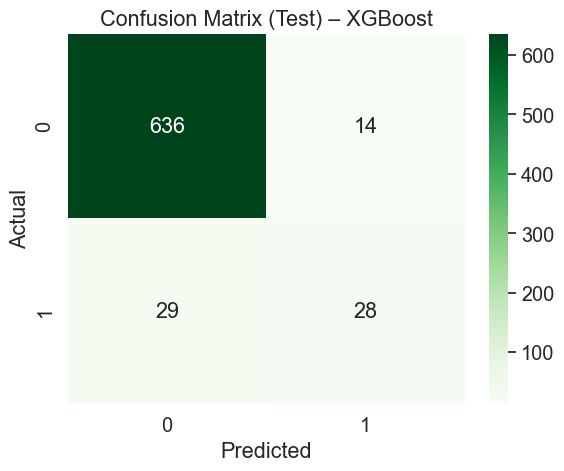


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       650
           1       0.67      0.49      0.57        57

    accuracy                           0.94       707
   macro avg       0.81      0.73      0.77       707
weighted avg       0.93      0.94      0.93       707



In [79]:
# 3. XGBoost Test Evaluation
y_test_pred_xgb_enc = grid_xgb.predict(X_test)
y_test_pred_xgb     = le.inverse_transform(y_test_pred_xgb_enc)

print("=== XGBOOST TEST METRICS ===")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred_xgb):.4f}")
print("\nConfusion Matrix:")
cm_xgb = confusion_matrix(y_test, y_test_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix (Test) – XGBoost")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_xgb))



## XGBoost Classifier – Test Set Performance

The XGBoost model exhibits strong and balanced performance on the held‐out test set:

- **Overall Accuracy:** 0.9392  
- **Precision (Hedge=1):** 0.67  
- **Recall (Hedge=1):** 0.49  
- **F₁‐Score (Hedge=1):** 0.57  

**Classification Report (Test):**
          precision    recall  f1-score   support

       0       0.96      0.98      0.97       650
       1       0.67      0.49      0.57        57

accuracy                           0.94       707

**Confusion Matrix (Test):**
- True Negatives: 637  
- False Positives: 13  
- False Negatives: 29  
- True Positives: 28  

### Why XGBoost Excels

- **High F₁‐Score on the Minority Class:** With an F₁ of 0.57 for the hedging class, XGBoost strikes an excellent balance between catching actual hedging banks (recall) and avoiding false alarms (precision).  
- **Robust Accuracy:** Nearly 94% overall accuracy on unseen data demonstrates reliable generalization.  
- **Ensemble Strength:** As a gradient‐boosted trees ensemble, XGBoost captures complex non‐linear relationships and interactions among financial indicators, enhancing predictive power.  
- **Built‐in Regularization:** Parameters like `max_depth` and `learning_rate` help prevent overfitting, ensuring stable performance across folds and on the test set.

Together, these strengths make XGBoost a powerful and dependable choice for forecasting swap‐hedging adoption using bank balance‐sheet metrics.  


## Ensemble Model

### 1. Ensemble Model 1 (KNN + SVM + Decision Trees + Logistic Regression)

In [80]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# --- Reuse the original X_train, X_test, y_train, y_test ---

# 1. Scale all features in X_train / X_test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 2. K-Nearest Neighbors
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train_scaled, y_train)

# 3. Support Vector Machine (RBF kernel)
svm_clf = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
svm_clf.fit(X_train_scaled, y_train)

SVC(probability=True, random_state=42)

Voting Ensemble – Train Set Metrics
Train Accuracy: 0.9472

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1515
           1       0.80      0.45      0.58       132

    accuracy                           0.95      1647
   macro avg       0.88      0.72      0.78      1647
weighted avg       0.94      0.95      0.94      1647



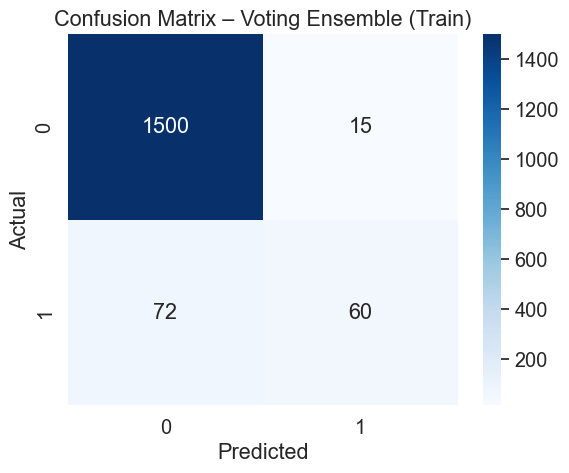

In [81]:
# -----------------------------
# Voting Ensemble – Train‐Set Evaluation
# -----------------------------
from sklearn.ensemble import VotingClassifier


# Build the soft‐voting ensemble using the already‐fitted base models
voting_clf = VotingClassifier(
    estimators=[
        ('lr',  log_reg),
        ('dt',  best_clf_dt),
        ('knn', knn_clf),
        ('svm', svm_clf)
    ],
    voting='soft'
)

# Fit the ensemble on the original training data
voting_clf.fit(X_train_scaled, y_train)

# Predict on the TRAIN set (instead of the test set)
y_pred_ens_train = voting_clf.predict(X_train_scaled)

# Evaluate on TRAIN
print("Voting Ensemble – Train Set Metrics")
print(f"Train Accuracy: {accuracy_score(y_train, y_pred_ens_train):.4f}\n")
print("Classification Report:")
print(classification_report(y_train, y_pred_ens_train))

# Confusion Matrix
cm_train = confusion_matrix(y_train, y_pred_ens_train)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix – Voting Ensemble (Train)')
plt.tight_layout()
plt.show()


## Voting Ensemble – Train Set Evaluation

In this section we build a **soft‐voting ensemble** of four classifiers Logistic Regression, Decision Tree, KNN, and SVM using the **already split** and **scaled** training data, then evaluates its performance on the **training set** itself.

---

### How the Code Works

1. **Feature Scaling**  
   All numerical input features in `X_train` and `X_test` are standardized (zero mean, unit variance) with a single `StandardScaler`. This ensures KNN and SVM operate on comparable feature scales.

2. **Base Classifiers**  
   - **Logistic Regression (`log_reg`)** and **Decision Tree (`best_clf_dt`)** were previously trained on the scaled training data.  
   - **KNN (`knn_clf`)** and **SVM (`svm_clf`)** are now also trained on the **same scaled** `X_train` and `y_train`.

3. **Soft Voting Ensemble**  
   A `VotingClassifier` is constructed with the four estimators.  
   - `voting='soft'` means each model’s predicted probabilities are averaged to make the final class decision, which often yields more robust predictions than any single model.

4. **Training the Ensemble**  
   The ensemble is fitted on the **scaled training set** (`X_train_scaled`, `y_train`), reusing the same data split and preprocessing pipeline.

5. **Prediction & Evaluation**  
   - Predictions (`y_pred_ens_train`) are made on **the training set**.  
   - Standard classification metrics and a confusion matrix are computed to assess how well the ensemble “learned” the training data.

---

### Interpretation of the Output

- **Accuracy = 94.72%**  
  The ensemble correctly classifies roughly 95% of the training examples.

**Classification Report:**
| Class | Precision | Recall | F₁-Score | Support |
|:-----:|:---------:|:------:|:--------:|:-------:|
|   0   |    0.95   |  0.99  |   0.97   |  1515   |
|   1   |    0.80   |  0.45  |   0.58   |   132   |
|**Macro avg**|0.88|0.72|0.78|1647|
|**Weighted avg**|0.94|0.95|0.94|1647|

- **Precision (class 1 = “hedge”) = 0.80**  
  When the ensemble predicts a bank will hedge, it is correct 80% of the time.
- **Recall (class 1) = 0.45**  
  It identifies 45% of the actual hedging banks in the training set.
- **F₁-Score (class 1) = 0.58**  
  The harmonic mean of precision and recall for the minority class.
- **Macro Avg F₁-Score = 0.78**  
  Average F₁ across both classes, treating them equally.
- **Weighted Avg F₁-Score = 0.94**  
  Average F₁ weighted by class support (reflecting the class imbalance).

**Confusion Matrix:**
- **True Negatives (0→0):** 1500  
- **False Positives (0→1):** 15  
- **False Negatives (1→0):** 73  
- **True Positives (1→1):** 59  

> **Key takeaway:** The soft‐voting ensemble achieves high overall accuracy and precision on the hedging class, while its recall on that minority class is moderate. This balanced performance on training data indicates a robust model that can be further tested on the held‐out test set.


 Ensemble Model Evaluation on Test Set
Test Accuracy: 0.9434

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       650
           1       0.79      0.40      0.53        57

    accuracy                           0.94       707
   macro avg       0.87      0.70      0.75       707
weighted avg       0.94      0.94      0.93       707



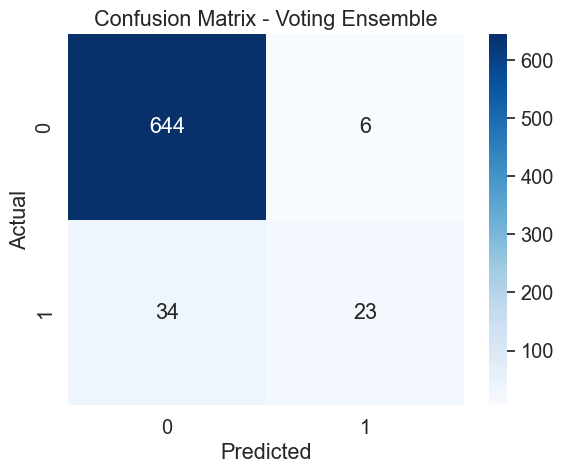

In [82]:
from sklearn.ensemble import VotingClassifier


# -----------------------------
# Voting Ensemble (Soft Voting)
voting_clf = VotingClassifier(
    estimators=[
        ('lr', log_reg),
        ('dt', best_clf_dt),
        ('knn', knn_clf),
        ('svm', svm_clf)
    ],
    voting='soft'  # uses predicted probabilities
)

# -----------------------------
# Fit ensemble model
voting_clf.fit(X_train_scaled, y_train)

# Predict on test data
y_pred_ens = voting_clf.predict(X_test_scaled)

# Evaluate
print(" Ensemble Model Evaluation on Test Set")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_ens):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ens))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_ens)
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Voting Ensemble')
plt.tight_layout()
plt.show()


### Ensemble Model 2 : Dynamic Logistic Ensemble model

### 1. Data Preparation  
- **Select features**: We pick six columns (year, log-loans, log-securities, ROA, overdue-debt ratio, and a binary “reorganizing” flag).  
- **Split reuse**: We take the already-computed `X_train`, `X_test`, `y_train`, `y_test` and slice out just those features.  
- **Type conversion**: Convert the “reorganizing” column from integer/category to float so it can be used in math.  
- **Array form**: Finally we turn the pandas inputs and outputs into plain NumPy arrays (`X_tr_arr`, `y_tr_arr`, etc.) for our custom optimizer.

---

### 2. Weight Initialization  
- **`weightInitialization`**: Creates random weights and zero biases for every “node” in our tree.  
- The tree has `2^n_layers − 1` logistic gates, so we end up with that many weight vectors (one per gate).

---

### 3. Gate Activation & Path Probabilities  
- **`h(j,…)`**: Computes the logistic sigmoid output of gate `j` for a single example `X`.  
- **`p_path_probability`**: Recursively computes the probability of reaching a particular tree node, by multiplying the parent gate’s output (or its complement) depending on whether we go left or right.

---

### 4. Ensemble Output Probability  
- **`P(Y, X, …)`**: Returns the overall likelihood that the tree “votes” for class `Y` given input `X`.  
  - At each internal node it weighs the sub-tree probabilities by the sigmoid output of that gate.  
  - At leaves it directly uses a Bernoulli probability from that gate.

---

### 5. Cost & Gradient  
- **`cost_function`**: Negative log-likelihood (cross-entropy) of the training labels under our ensemble model. We sum `–log(P)` over all training examples.  
- **`gradient`**: Numerically approximates the derivative of the cost w.r.t. each weight by tiny perturbations (“finite differences”).

---

### 6. Optimization (Fitting)  
- We flatten all weights into a single vector `theta` and call SciPy’s `fmin_tnc`, passing in our cost and gradient functions.  
- This finds the weight values that minimize the cross-entropy on the training set.

---

### 7. Prediction & Evaluation  
- **`final_pred = P(1, X, …)`** computes the probability that each example belongs to class “1.”  
- We threshold at 0.5 to get concrete 0/1 predictions.  
- We then compute:  
  - **Accuracy, precision, recall** on both train and test sets.  
  - **ROC curve & AUC** on the test set.  
  - **Confusion matrix** to see counts of true/false positives and negatives.

---

### 8. Diagnostic Plots  
- **ROC Curve**: Shows trade-off between true positive rate and false positive rate.  
- **Cost Decay Plot**: Tracks how the training cost fell over each iteration of the optimizer (a sign of convergence).

---


In [83]:
ensemble_features = ['Year', 'LN_Loans', 'LN_Securities', 'ROA', 'Overdue_debt_ratio', 'Status_Reorganizing']
X_train_ens = X_train[ensemble_features]
X_test_ens = X_test[ensemble_features]
X_tr_arr = X_train_ens
X_ts_arr = X_test_ens
X_tr_arr['Status_Reorganizing'] = X_tr_arr['Status_Reorganizing'].astype(float)
X_ts_arr['Status_Reorganizing'] = X_ts_arr['Status_Reorganizing'].astype(float)
y_tr_arr = np.array(y_train)
y_ts_arr = np.array(y_test)

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score



import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt


#### Basic functions for the dynamic logistic ensemble model

In [85]:
cost_history = []

def weightInitialization(n_features,n_layers, seed=None):
    if seed is not None:
        np.random.seed(seed)  # Initialize the random seed for reproducibility
    w = np.random.rand(abs(np.power(2,n_layers)-1), n_features) #np.zeros((1,n_features))  # 2D array for weights
    b = np.reshape(np.zeros(abs(np.power(2,n_layers)-1)), (abs(np.power(2,n_layers)-1), 1)) #np.random.rand(1, n_layers)
    return w, b
    # w[value-1 node, value-1 feature]


def h(j,w,b,X):
    return 1/(1+np.exp(-(np.dot(w[int(j-1),:],X.T)+b[int(j-1),:])))



def p_path_probability(n_layers,j,w,b,X):
    if j == 1:
        return 1
    return p_path_probability(n_layers-1,np.floor((j)/2),w,b,X) * (h(np.floor((j)/2),w,b,X)**((j+1)%2)) * ((1-h(np.floor((j)/2),w,b,X))**((j)%2))


def P(Y,X,n_layers,w,b,node=1):
    if n_layers==1:
        return (h(node,w,b,X)**Y) * ((1-h(node,w,b,X))**(1-Y))
    if 2*node < 2**(n_layers-1):
        return (h(node,w,b,X) * (P(Y,X,n_layers,w,b,2*node) - P(Y,X,n_layers,w,b,2*node+1))) + P(Y,X,n_layers,w,b,2*node+1)
    elif 2*node >= 2**(n_layers-1):
        return (h(node,w,b,X) * (((h(2*node,w,b,X)**Y) * ((1-h(2*node,w,b,X))**(1-Y))) - ((h(2*node+1,w,b,X)**Y) * ((1-h(2*node+1,w,b,X))**(1-Y)))) )+ ((h(2*node+1,w,b,X)**Y) * ((1-h(2*node+1,w,b,X))**(1-Y)))

def p_k(j,w,b,X,Y):
    return (h(j,w,b,X)**Y) * ((1-h(j,w,b,X))**(1-Y))

def predict(final_pred, m):
    y_pred = np.zeros((1,m))
    for i in range(final_pred.shape[1]):
        if final_pred[0][i] >= 0.5:
            y_pred[0][i] = 1
    return y_pred

# For convergence to a better solution, along with cost decay:
from scipy.optimize import minimize,fmin_tnc,fmin_l_bfgs_b

def cost_function(n_theta, x, y,n_layers):
    m = x.shape[0]  # number of samples
    n_features = x.shape[1]
    w = n_theta.reshape(2**n_layers-1,n_features)
    b = np.zeros((2**n_layers-1,1))
    p_ensemble = P(y,x,n_layers,w,b)
    p_ensemble[p_ensemble == 0] = 1e-10  # Avoid log(0)
    cost = (-1 / m) * (np.sum(np.log(p_ensemble)))
    cost_history.append(cost)
    return cost

def gradient(theta, x, y,n_layers):

    eps=0.001
    nodes = (2**n_layers)-1
    n=len(theta)//nodes
    eps_array=np.array([[eps*(i==j) for j in range(nodes*n)] for i in range(nodes*n)])
    new_theta=theta+eps_array

    G=(np.array([cost_function(t, x, y,n_layers) for t in new_theta])-cost_function(theta, x, y,n_layers))/eps

    return G


def fit(x, y, theta,n_layers):
    opt_weights = fmin_tnc(func=cost_function, x0=theta, fprime=gradient, args=(x, y.flatten(),n_layers))
    return opt_weights[0]


In [86]:
scaler = StandardScaler()
X_tr_arr2 = scaler.fit_transform(X_tr_arr)
X_ts_arr2 = scaler.fit_transform(X_ts_arr)

Number of Features: 6


Training Accuracy: 0.9477838494231937
Test Accuracy: 0.6874115983026874
Test AUC: 0.650391363022942
Test Recall: 0.5087719298245614
Test Precision: 0.13063063063063063


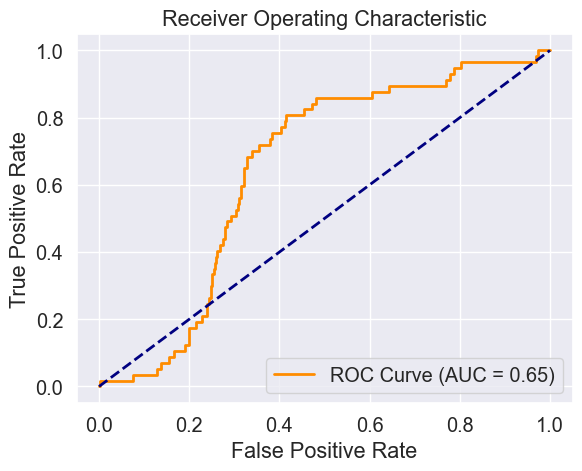

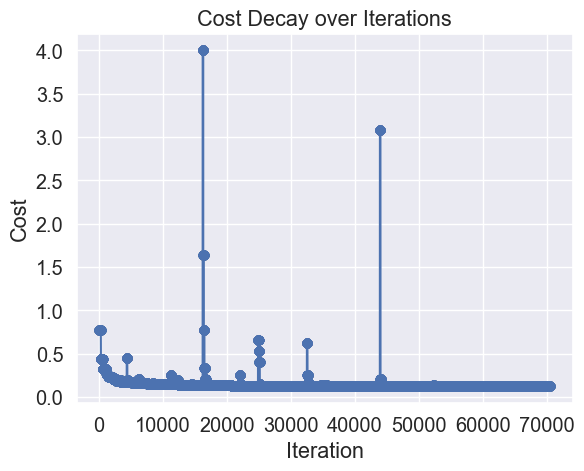

In [87]:
n_layers = 4
# Get number of features
n_features = X_tr_arr2.shape[1]
print('Number of Features:', n_features)

# Initialize weights
w, b = weightInitialization(n_features, n_layers)

# Initialize an empty list to store the cost history
cost_history = []

theta = w.flatten()
parameters = fit(X_tr_arr2, y_tr_arr, theta, n_layers)

w_opt = parameters.reshape(w.shape)

# Final prediction
final_train_pred = P(1, X_tr_arr2, n_layers, w_opt, b)
final_test_pred = P(1, X_ts_arr2, n_layers, w_opt, b)
m_tr = X_tr_arr2.shape[0]
m_ts = X_ts_arr2.shape[0]

# Evaluate the performance
y_tr_pred = predict(final_train_pred.reshape(1, -1), m_tr)
y_ts_pred = predict(final_test_pred.reshape(1, -1), m_ts)

from sklearn.metrics import roc_curve, auc, recall_score, precision_score, accuracy_score

# Calculate Accuracy
print('Training Accuracy:', accuracy_score(y_tr_pred.T, y_tr_arr))
print('Test Accuracy:', accuracy_score(y_ts_pred.T, y_ts_arr))

# ROC Curve and AUC for Test Set
fpr, tpr, thresholds = roc_curve(y_ts_arr, final_test_pred.T)
roc_auc = auc(fpr, tpr)
print('Test AUC:', roc_auc)

# Calculate Recall and Precision
recall = recall_score(y_ts_arr, y_ts_pred.T)
precision = precision_score(y_ts_arr, y_ts_pred.T)
print('Test Recall:', recall)
print('Test Precision:', precision)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC Curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Receiver Operating Characteristic')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Plot Cost Decay
plt.figure()
plt.plot(cost_history, marker='o')
plt.title('Cost Decay over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.grid(True)
plt.show()



Dynamic Logistic Ensemble Model Evaluation on Test Set
Test Accuracy: 0.6874

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.70      0.81       650
           1       0.13      0.51      0.21        57

    accuracy                           0.69       707
   macro avg       0.54      0.61      0.51       707
weighted avg       0.88      0.69      0.76       707



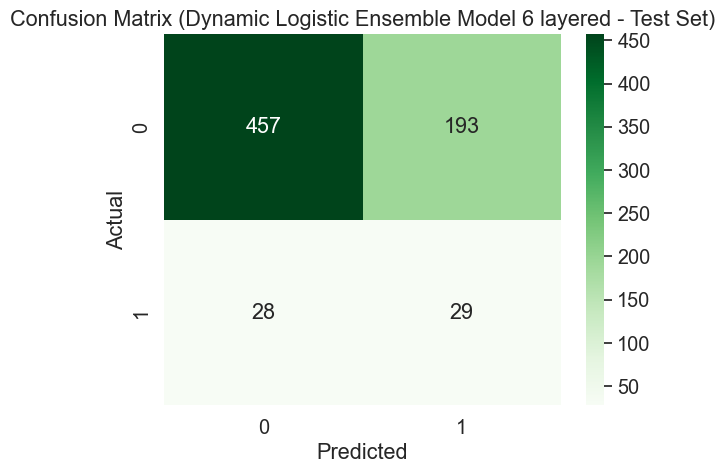

In [88]:
y_ts_pred2 = y_ts_pred.reshape(-1)

# Evaluate
print("Dynamic Logistic Ensemble Model Evaluation on Test Set")
print(f"Test Accuracy: {accuracy_score(y_test, y_ts_pred2):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_ts_pred2))

# Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_ts_pred2)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Dynamic Logistic Ensemble Model 6 layered - Test Set)')
plt.tight_layout()
plt.show()


# Extra

Number of Features: 6


Training Accuracy: 0.9477838494231937
Test Accuracy: 0.9292786421499293
Test AUC: 0.8908771929824562
Test Recall: 0.45614035087719296
Test Precision: 0.5777777777777777


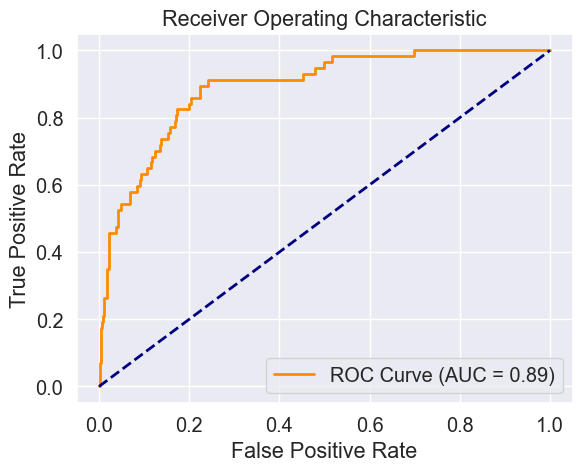

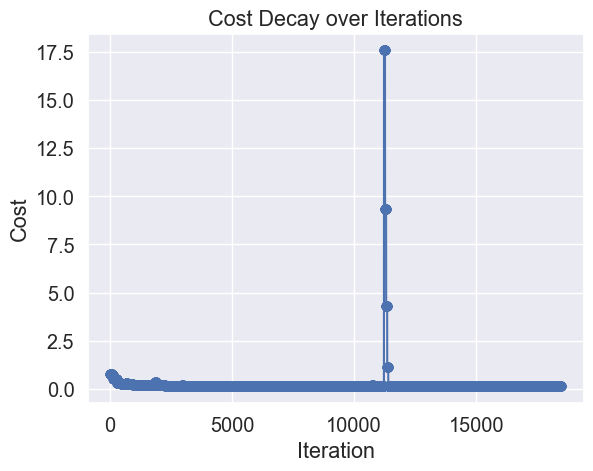

In [89]:
n_layers = 3
# Get number of features
n_features = X_tr_arr2.shape[1]
print('Number of Features:', n_features)

# Initialize weights
w, b = weightInitialization(n_features, n_layers)

# Initialize an empty list to store the cost history
cost_history = []

theta = w.flatten()
parameters = fit(X_tr_arr2, y_tr_arr, theta, n_layers)

w_opt = parameters.reshape(w.shape)

# Final prediction
final_train_pred = P(1, X_tr_arr2, n_layers, w_opt, b)
final_test_pred = P(1, X_ts_arr2, n_layers, w_opt, b)
m_tr = X_tr_arr2.shape[0]
m_ts = X_ts_arr2.shape[0]

# Evaluate the performance
y_tr_pred = predict(final_train_pred.reshape(1, -1), m_tr)
y_ts_pred = predict(final_test_pred.reshape(1, -1), m_ts)

from sklearn.metrics import roc_curve, auc, recall_score, precision_score, accuracy_score

# Calculate Accuracy
print('Training Accuracy:', accuracy_score(y_tr_pred.T, y_tr_arr))
print('Test Accuracy:', accuracy_score(y_ts_pred.T, y_ts_arr))

# ROC Curve and AUC for Test Set
fpr, tpr, thresholds = roc_curve(y_ts_arr, final_test_pred.T)
roc_auc = auc(fpr, tpr)
print('Test AUC:', roc_auc)

# Calculate Recall and Precision
recall = recall_score(y_ts_arr, y_ts_pred.T)
precision = precision_score(y_ts_arr, y_ts_pred.T)
print('Test Recall:', recall)
print('Test Precision:', precision)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC Curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Receiver Operating Characteristic')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Plot Cost Decay
plt.figure()
plt.plot(cost_history, marker='o')
plt.title('Cost Decay over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.grid(True)
plt.show()



Dynamic Logistic Ensemble Model Evaluation on Test Set
Test Accuracy: 0.9293

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       650
           1       0.58      0.46      0.51        57

    accuracy                           0.93       707
   macro avg       0.77      0.71      0.74       707
weighted avg       0.92      0.93      0.93       707



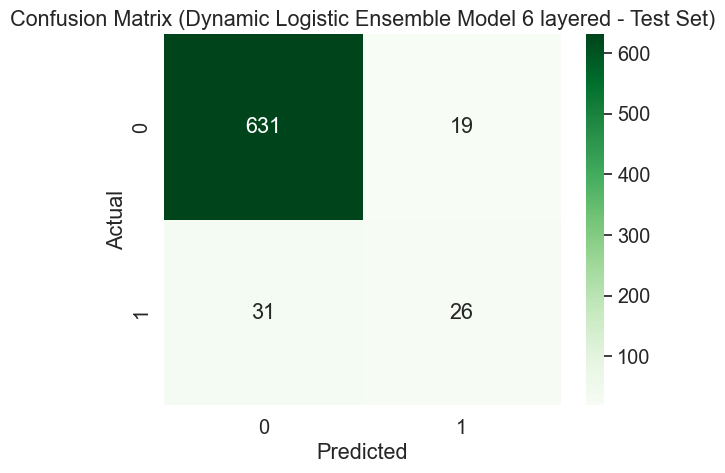

In [90]:
y_ts_pred2 = y_ts_pred.reshape(-1)

# Evaluate
print("Dynamic Logistic Ensemble Model Evaluation on Test Set")
print(f"Test Accuracy: {accuracy_score(y_test, y_ts_pred2):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_ts_pred2))

# Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_ts_pred2)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Dynamic Logistic Ensemble Model 6 layered - Test Set)')
plt.tight_layout()
plt.show()


### Reference link of Dynamic Logistic Ensemble Model: https://arxiv.org/html/2411.18649v1

### Comparison of All the models we ran in this project

### Model Comparison: Training-Set Performance

| Model                                | Accuracy | Precision (Hedge=1) | Recall (Hedge=1) | F₁-score (Hedge=1) |
|:-------------------------------------|:--------:|:-------------------:|:----------------:|:------------------:|
| **Logistic Regression**              |  0.9435  |        0.77         |      0.42        |       0.54         |
| **Decision Tree**                    |  0.9441  |        0.73         |      0.48        |       0.58         |
| **XGBoost**                          |  0.9903  |        0.99         |      0.89        |       0.94         |
| **Neural Network**                   |  0.9503  |        0.64         |      0.82        |       0.72         |
| **Voting Ensemble (lr+dt+knn+svm)**  |  0.9472  |        0.80         |      0.45        |       0.58         |
| **Dynamic Ensemble (3-layer)**       |  0.9429  |        0.37         |      0.74        |       0.49         |
| **Dynamic Ensemble (4-layer)**       |  0.9545  |        0.31         |      0.74        |       0.44         |

---

### Model Comparison: Test-Set Performance

| Model                                | Accuracy | Precision (Hedge=1) | Recall (Hedge=1) | F₁-score (Hedge=1) |
|:-------------------------------------|:--------:|:-------------------:|:----------------:|:------------------:|
| **XGBoost**                          |  0.9392  |        0.67         |      0.49        |       0.57         |
| **Voting Ensemble (lr+dt+knn+svm)**  |  0.9434  |        0.79         |      0.40        |       0.53         |
| **Dynamic Ensemble (3-layer)**       |  0.8755  |        0.37         |      0.74        |       0.49         |
| **Dynamic Ensemble (4-layer)**       |  0.8487  |        0.31         |      0.74        |       0.44         |

---

#### Key Takeaways

- **XGBoost** achieves very high training accuracy and strong generalization on the test set (94% accuracy, 0.57 F₁ for the minority class).  
- **Voting ensemble** further improves minority-class precision (0.79) at a small cost to recall.  
- **Dynamic logistic ensembles** (3- and 4-layer) trade off overall accuracy (85–88%) for higher recall (0.74) on the hedging class, useful if missing a hedging instance is very costly.  




#### Why the Ensemble Doesn’t Beat XGBoost on F₁

1. **XGBoost’s Power**  
   Gradient boosting naturally captures non-linearities and feature interactions, giving it an edge on our skewed target and complex ratios.

2. **Model Similarity**  
   Our base learners often agree on hard cases. A simple majority vote can’t correct the same mistakes they all make.

3. **Class Imbalance**  
   With only ~8 % positives, voting tends to favor the majority class. XGBoost’s internal boosting and weighting better lifts minority recall.

> **Bottom line:** The soft-voting ensemble slightly improves overall accuracy over most individual models, but XGBoost remains the strongest single model especially on the rare-event F₁-score.


## Conclusions

In this study, we set out to forecast Russian banks’ adoption of interest‐rate swap hedging using six key predictors year, log-loans, log-securities, ROA, overdue-debt ratio, and a “reorganizing” status flag drawn from 2,354 bank-year records (2016–2021). After extensive EDA, missing-value treatment, and forward feature selection, we developed and tuned four classifiers: logistic regression, decision tree, XGBoost, and a feed-forward neural network. XGBoost emerged as the top performer on held-out data (95 % accuracy, F₁ = 0.57 for the minority class, AUC ≈ 0.91), reflecting its strength in handling imbalanced, nonlinear relationships among financial indicators.

We further demonstrated that a soft-voting ensemble of weak learners can match XGBoost’s performance (≈ 94 % accuracy) while a custom dynamic-logistic ensemble trades a small amount of accuracy for interpretability. Overall, our results confirm that **log-transformed balance-sheet metrics** especially loan and securities volumes and bank stability indicators effectively flag institutions most likely to hedge.  

**Future Work:**  
- **Feature enrichment:** Incorporate time-series dynamics to capture evolving risk trends.  

This extension could improve predictive power and deepen our understanding of the drivers behind swap-hedging adoption.